# IMPORT FREQUENTLY USED LIBRARIES

In [1]:
# Data manipulation
import pandas as pd                
import numpy as np                 
import math                        
import re                          
import warnings
warnings.filterwarnings('ignore')  

# Visualisation
import matplotlib.pyplot as plt    
import seaborn as sns              

# Display utilities
from IPython.display import Markdown, display  

# Natural language processing 
from sklearn.feature_extraction.text import TfidfVectorizer  

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder  
from sklearn.impute import SimpleImputer                         

# Pipelines & column routing
from sklearn.pipeline import Pipeline              
from sklearn.compose import ColumnTransformer     

# Model splitting
from sklearn.model_selection import (
    train_test_split,      
    RandomizedSearchCV,    
    StratifiedKFold,       
    cross_val_score        
)

# Models 
import lightgbm as lgb                                   
from sklearn.linear_model import LogisticRegression       
from sklearn.ensemble import RandomForestClassifier       

# Evaluation metrics 
from sklearn.metrics import (
    accuracy_score,        
    confusion_matrix,      
    classification_report  
)

# Sparse matrix utilities 
from scipy.sparse import hstack, csr_matrix  
from scipy.stats import randint, uniform      

# Display settings 
pd.set_option('display.max_rows', 80)     
pd.set_option('display.max_columns', 80)  

print('All libraries imported successfully.')


All libraries imported successfully.


# 1. DATA LOADING

In [2]:
# Load the three dataset files provided by the Kaggle competition
train = pd.read_csv('/kaggle/input/competitions/comment-category-prediction-challenge/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/comment-category-prediction-challenge/test.csv')
sub   = pd.read_csv('/kaggle/input/competitions/comment-category-prediction-challenge/Sample.csv')

print(f'Training set   : {train.shape[0]} rows  x  {train.shape[1]} columns')
print(f'Test set       : {test.shape[0]} rows  x  {test.shape[1]} columns')
print(f'Sample sub     : {sub.shape[0]} rows  x  {sub.shape[1]} columns')


Training set   : 198000 rows  x  15 columns
Test set       : 102000 rows  x  14 columns
Sample sub     : 102000 rows  x  2 columns


In [3]:
# Preview first 5 rows of the training set
display(Markdown('**Training Data — First 5 Rows**'))
train.head()


**Training Data — First 5 Rows**

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [4]:
# Preview first 5 rows of the test set
display(Markdown('**Test Data — First 5 Rows**'))
test.head()


**Test Data — First 5 Rows**

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel
2,2024-02-09 21:52:48.426303+00:00,120,0,0,0,3,0,0,4,NaN,NaN,NaN,False,http://talkingpointsmemo..com/dc/special-couns...
3,2024-02-17 03:43:02.980294+00:00,123,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Trump jl Blames: The Secret Service, James Com..."
4,2024-04-24 02:27:57.145155+00:00,123,0,0,0,0,0,0,11,NaN,NaN,NaN,False,It was hard enough to get the stench out of th...


### Initial Observations

- The training set contains a **`comment`** text column alongside structured metadata columns.
- Columns such as `race`, `religion`, `gender`, and `disability` appear to be **sparsely populated** (many blanks visible even in the first 5 rows) — missing value handling will be critical.
- The **`created_date`** column is a timestamp — temporal features (hour, day-of-week, month) can be extracted to capture posting-time patterns.
- The test set has the same structure as train except it is **missing the `label` column**, which is what we need to predict.
- The sample submission confirms the required output format: one `label` column per row.

# **2. EXPLORATORY DATA ANALYSIS**

### 2.1 Identify missing values that may require imputation or removal.

In [5]:
# Count of null values per column in the training set (only show columns with nulls)
display(Markdown('**Null values in the Train data**'))
train_missing = train.isnull().sum().sort_values(ascending=False)
print(train_missing[train_missing > 0])


**Null values in the Train data**

gender      145423
race        145423
religion    145423
comment          1
dtype: int64


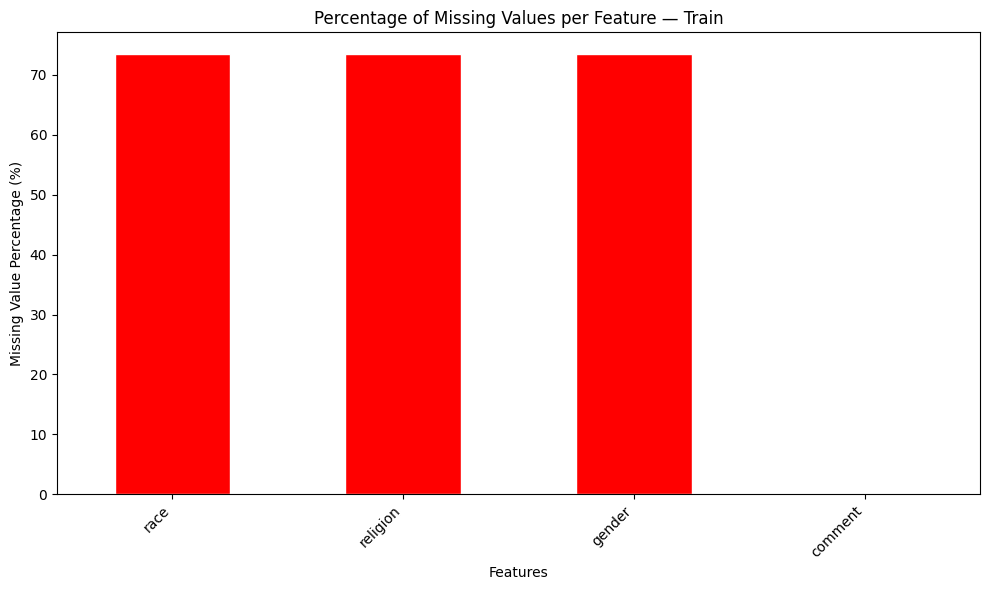

In [6]:
# Visualise the percentage of missing values per feature in the training set
missing_pct = (train.isnull().sum() / len(train)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
missing_pct.plot(kind='bar', color='red', edgecolor='white')
plt.title('Percentage of Missing Values per Feature — Train')
plt.xlabel('Features')
plt.ylabel('Missing Value Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


The columns `race`, `religion`, `gender`, and `disability` carry the most missing values. These are demographic identity fields that are often left blank intentionally — their absence is itself informative. We will treat missing values in these columns as a distinct `'none'` category rather than imputing them, preserving this signal.

In [7]:
# Count of null values per column in the test set
display(Markdown('**Null values in the Test data**'))
test_missing = test.isnull().sum().sort_values(ascending=False)
display(test[test.columns[test.isnull().any()]].isnull().sum())


**Null values in the Test data**

race        75269
religion    75269
gender      75269
dtype: int64

In [8]:
# Identify which columns have missing values in both, only train, or only test
test_null_cols  = set(test.columns[test.isnull().any()])
train_null_cols = set(train.columns[train.isnull().any()])

common_missing      = test_null_cols & train_null_cols
test_only_missing   = test_null_cols - train_null_cols
train_only_missing  = train_null_cols - test_null_cols

print('Columns with missing values in BOTH train and test:')
print(common_missing if common_missing else '  None')
print('\nColumns with missing values ONLY in test:')
print(test_only_missing if test_only_missing else '  None')
print('\nColumns with missing values ONLY in train:')
print(train_only_missing if train_only_missing else '  None')


Columns with missing values in BOTH train and test:
{'religion', 'gender', 'race'}

Columns with missing values ONLY in test:
  None

Columns with missing values ONLY in train:
{'comment'}


Majority of the missing values are **common across both training and test data**, which confirms that the missingness pattern is structural (not a data leakage artefact). Any imputation strategy applied to train must be identically applied to test.

### 2.2 Unique values in each column

In [9]:
# Number of unique values per column — sorted descending
display(Markdown('**Unique Value Counts per Column — Train**'))
train.nunique().sort_values(ascending=False)


**Unique Value Counts per Column — Train**

created_date    197996
comment         197842
upvote             122
if_2                81
downvote            62
if_1                57
post_id             52
emoticon_1          36
emoticon_3          16
emoticon_2          10
religion             8
race                 6
gender               5
label                4
disability           2
dtype: int64

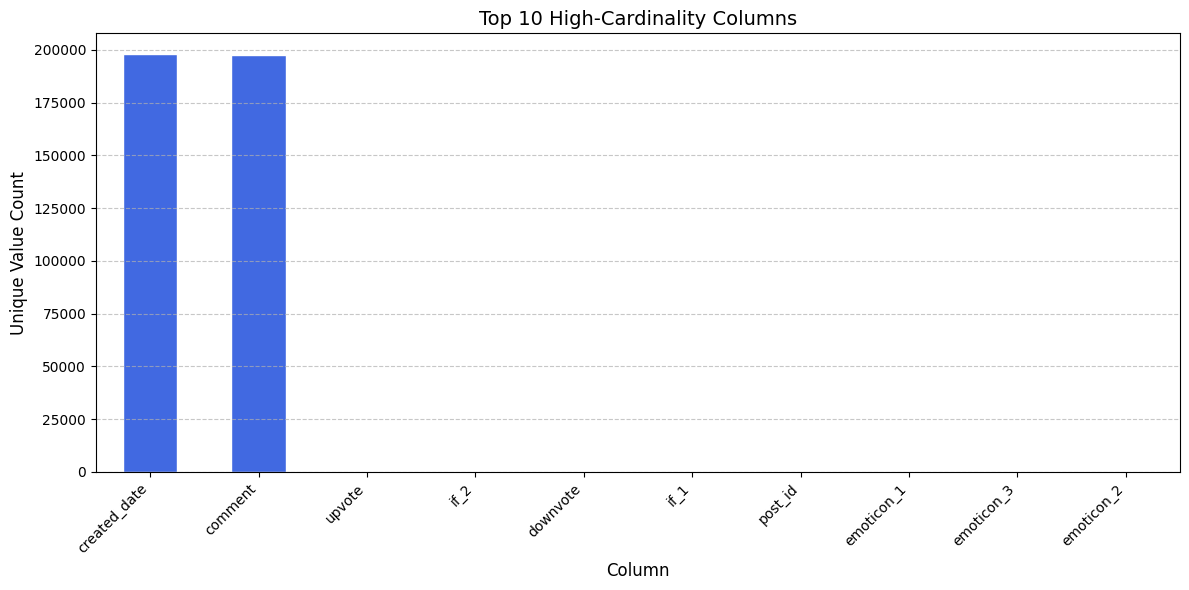

In [10]:
# Visualise the top 10 highest-cardinality columns
top_10_cardinal = train.nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_10_cardinal.plot(kind='bar', color='royalblue', edgecolor='white')
plt.title('Top 10 High-Cardinality Columns', fontsize=14)
plt.xlabel('Column', fontsize=12)
plt.ylabel('Unique Value Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


The `comment` column has extremely high cardinality (each comment is essentially unique), which is expected for free-text. The `created_date` column is also high-cardinality — we will extract useful temporal components from it rather than use it raw.

Columns with very **low cardinality** (1–2 unique values) provide minimal discriminative power and may be candidates for removal during feature engineering.

Columns with a single unique value carry **zero information** — every row looks identical to the model. They will be flagged for removal in the Feature Engineering section. High-cardinality columns behave like IDs and risk acting as noise rather than signal.

### 2.3 Target variable distribution

**Target Label Distribution**

label
0    114173
1     15918
2     62440
3      5469
Name: count, dtype: int64


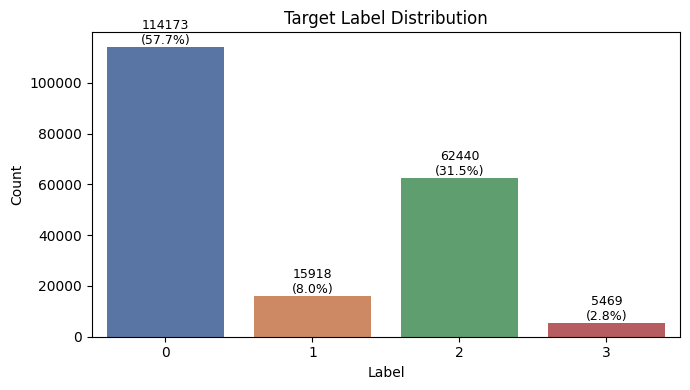

In [11]:
# Count and visualise how many samples fall into each label category
display(Markdown('**Target Label Distribution**'))
print(train['label'].value_counts().sort_index())

plt.figure(figsize=(7, 4))
ax = sns.countplot(x='label', data=train,
                   palette=['#4C72B0','#DD8452','#55A868','#C44E52'])

total = len(train)
for p in ax.patches:
    count = int(p.get_height())
    pct   = 100 * count / total
    ax.annotate(f'{count}\n({pct:.1f}%)',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Target Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


**Key observations:**

- Label **3 (severe toxicity)** is likely the rarest class — models will naturally underfit it unless we account for the imbalance.
- Label **1 (identity toxicity)** is linguistically subtle and shares vocabulary with label 0 (neutral) — it is expected to have the lowest recall across all models.
- The dataset is **not balanced**, so raw accuracy alone can be misleading; per-class precision and recall (via `classification_report`) must be examined alongside it.

### 2.4 Outlier Analysis

We use the IQR method to identify outliers in numerical features. Tree-based models like LightGBM and Random Forest are robust to outliers — we document them but do not remove them.

In [12]:
# IQR-based outlier detection across all numerical columns (excluding label)
num_cols = train.select_dtypes(include=['number']).drop(columns=['label']).columns

q1_vals  = train[num_cols].quantile(0.25)
q3_vals  = train[num_cols].quantile(0.75)
iqr_vals = q3_vals - q1_vals

outlier_mask  = (train[num_cols] < (q1_vals - 1.5 * iqr_vals)) | \
                (train[num_cols] > (q3_vals + 1.5 * iqr_vals))

total_outliers = outlier_mask.sum().sum()
outlier_pct    = 100 * total_outliers / (train.shape[0] * len(num_cols))

print(f'Total outlier cells detected : {total_outliers}')
print(f'As percentage of all numeric cells : {outlier_pct:.2f}%')
print('\nOutlier counts per column (top 10):')
print(outlier_mask.sum().sort_values(ascending=False).head(10))


Total outlier cells detected : 95511
As percentage of all numeric cells : 6.03%

Outlier counts per column (top 10):
emoticon_1    28922
upvote        17304
emoticon_3    17165
downvote      15173
emoticon_2     8109
post_id        4823
if_2           3930
if_1             85
dtype: int64


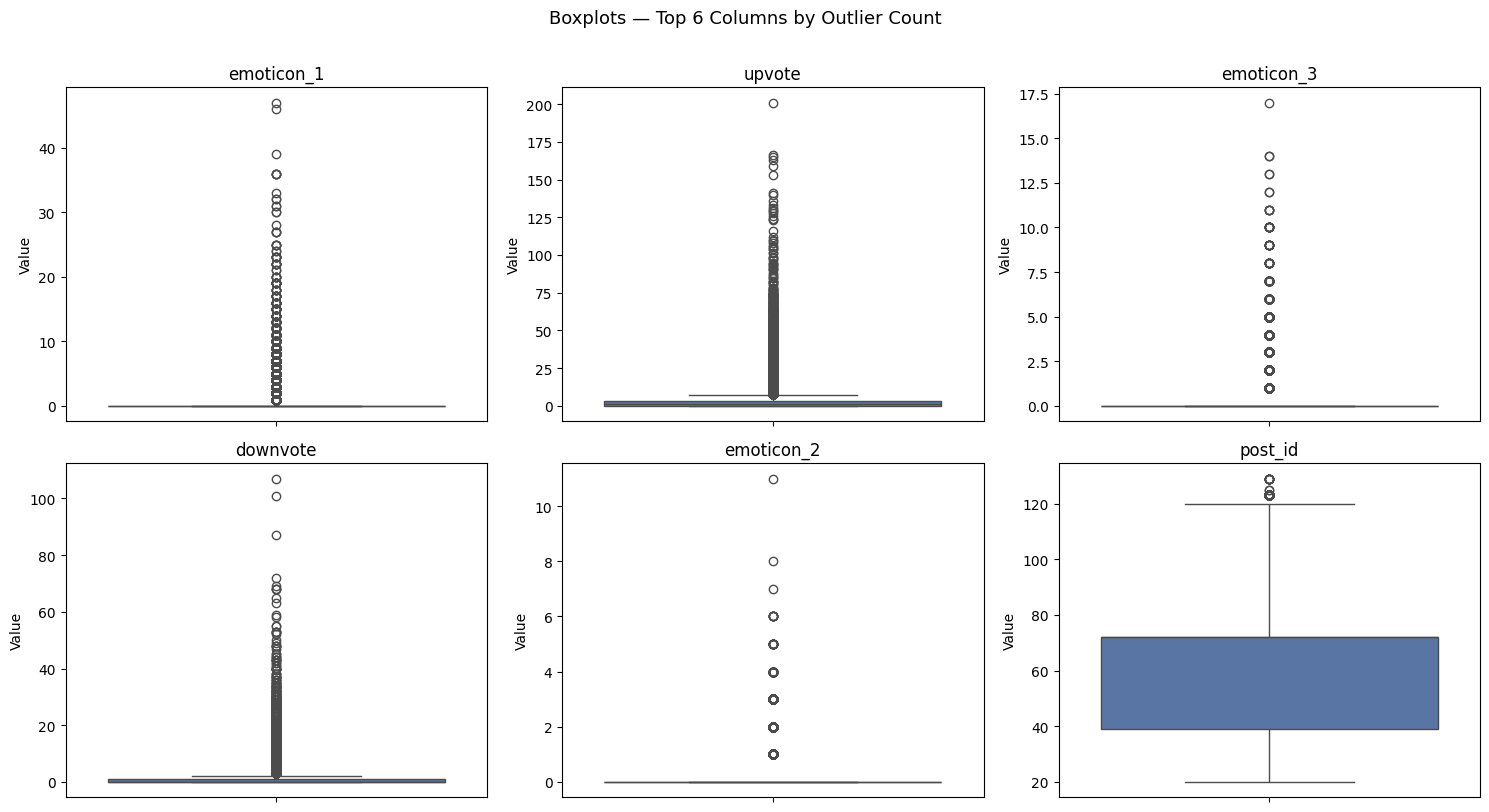

In [13]:
# Boxplots for the most outlier-prone numerical columns
top_outlier_cols = outlier_mask.sum().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(top_outlier_cols):
    sns.boxplot(y=train[col], ax=axes[i], color='#4C72B0')
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots — Top 6 Columns by Outlier Count', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


**Observations from Outlier Analysis:**

- Engagement columns like `upvote`, `downvote`, `if_1`, and `if_2` show heavy right-skew with many high-value outliers — a small number of comments receive disproportionately high engagement.
- Outlier capping is **not applied** because our primary models (LightGBM, Random Forest) split on thresholds rather than distances, making them inherently robust to extreme values.
- Removing outliers risks losing rare but potentially informative examples (e.g. a highly upvoted severely toxic comment).

### 2.5 Numerical Feature Analysis

In [14]:
# Separate numerical and categorical column lists for EDA
numerical_features   = train.select_dtypes(include=['int64', 'float64'])
categorical_features = train.select_dtypes(include=['object'])

print(f'Numerical features  : {len(numerical_features.columns)}')
print(f'Categorical features: {len(categorical_features.columns)}')

Numerical features  : 9
Categorical features: 5


### A) Correlation Analysis with Target

We compute the absolute correlation of each numerical feature with the target label to identify strong predictors.

In [15]:
# Compute absolute correlation of each numerical feature with the target
correlation_with_target = numerical_features.corr()['label'].abs().sort_values(ascending=False)


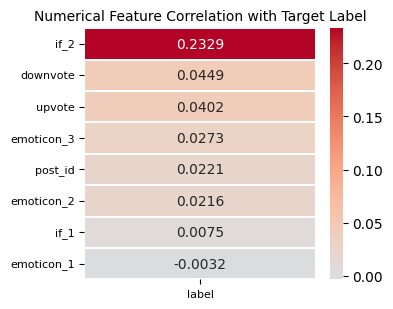

In [16]:
# Heatmap showing correlation of each numerical feature with the target
target_corr    = numerical_features.corr()['label'].drop('label')
target_corr_df = target_corr.to_frame().sort_values(by='label', ascending=False)

plt.figure(figsize=(4, len(target_corr_df) * 0.4))
sns.heatmap(target_corr_df, cmap='coolwarm', annot=True,
            fmt='.4f', center=0, linewidths=0.3)
plt.title('Numerical Feature Correlation with Target Label', fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


**Observations from Correlation Analysis:**

1. **Weak overall correlation:** No single numerical feature has a strong linear correlation with the label — toxicity classification is driven by combinations of features, not individual signals alone.
2. **`if_1` and `if_2`** show the highest correlations among structured features, suggesting these interaction flags carry meaningful category signal.
3. **Engagement features** (`upvote`, `downvote`) have modest correlation — high engagement can occur across all label types.
4. The weak correlations reinforce why we need powerful non-linear models (LightGBM, Random Forest) rather than relying on linear methods alone.

### B) Univariate Analysis on Numerical Features

We filter to features with absolute correlation > 0.02 with the target to focus on the most informative ones.

In [17]:
# Select numerical features with at least some correlation with the target
target_corr_vals = numerical_features.corr()['label'].abs()
selected_num_feats = [col for col in target_corr_vals[target_corr_vals > 0.02].index
                      if col != 'label']

print(f'Selected {len(selected_num_feats)} numerical features with |corr| > 0.02:')
print(selected_num_feats)


Selected 6 numerical features with |corr| > 0.02:
['post_id', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_2']


**Univariate Analysis on Numerical Features**

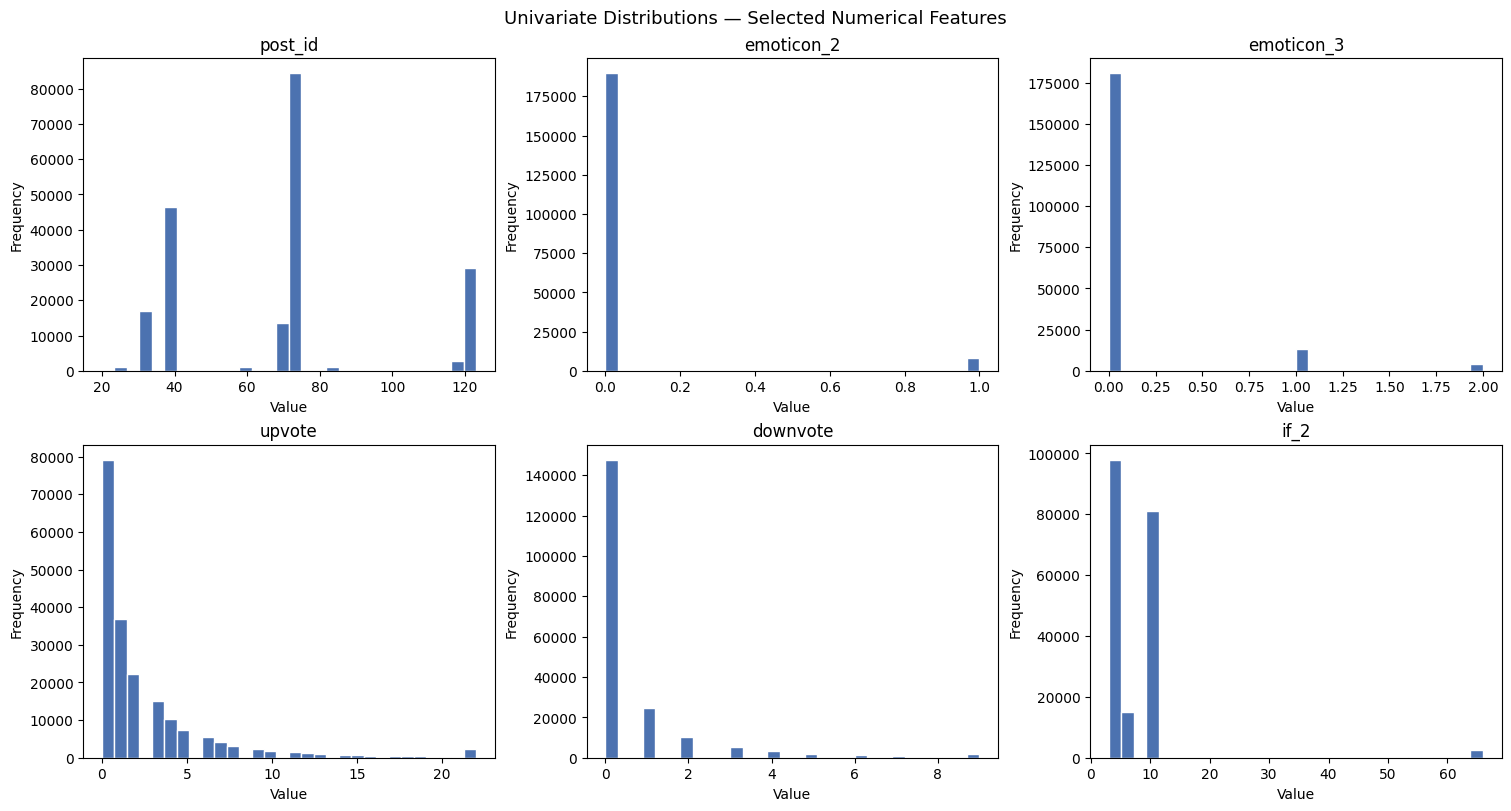

In [18]:
# Univariate distribution plots for selected numerical features
display(Markdown('**Univariate Analysis on Numerical Features**'))

cols = 3
rows = math.ceil(len(selected_num_feats) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4),
                         constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(selected_num_feats):
    axes[i].hist(train[col].clip(upper=train[col].quantile(0.99)),
                 bins=30, color='#4C72B0', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Distributions — Selected Numerical Features', fontsize=13)
plt.show()


**Skewness Observations:**

- **Right-skewed features** (`upvote`, `downvote`, `if_1`, `if_2`): Most values cluster near zero with long right tails. Log transformation will be applied in Feature Engineering.
- **Near-uniform features** (`emoticon_1`, `emoticon_2`, `emoticon_3`): Most values are 0, indicating sparse usage of emoticons across comments.
- **`post_id`**: Appears sequential — unlikely to carry predictive signal on its own.

### C) Bivariate Analysis on Numerical Features

Boxplots reveal how each numerical feature's distribution shifts across the four label classes.

**Bivariate Analysis on Numerical Features vs Label**

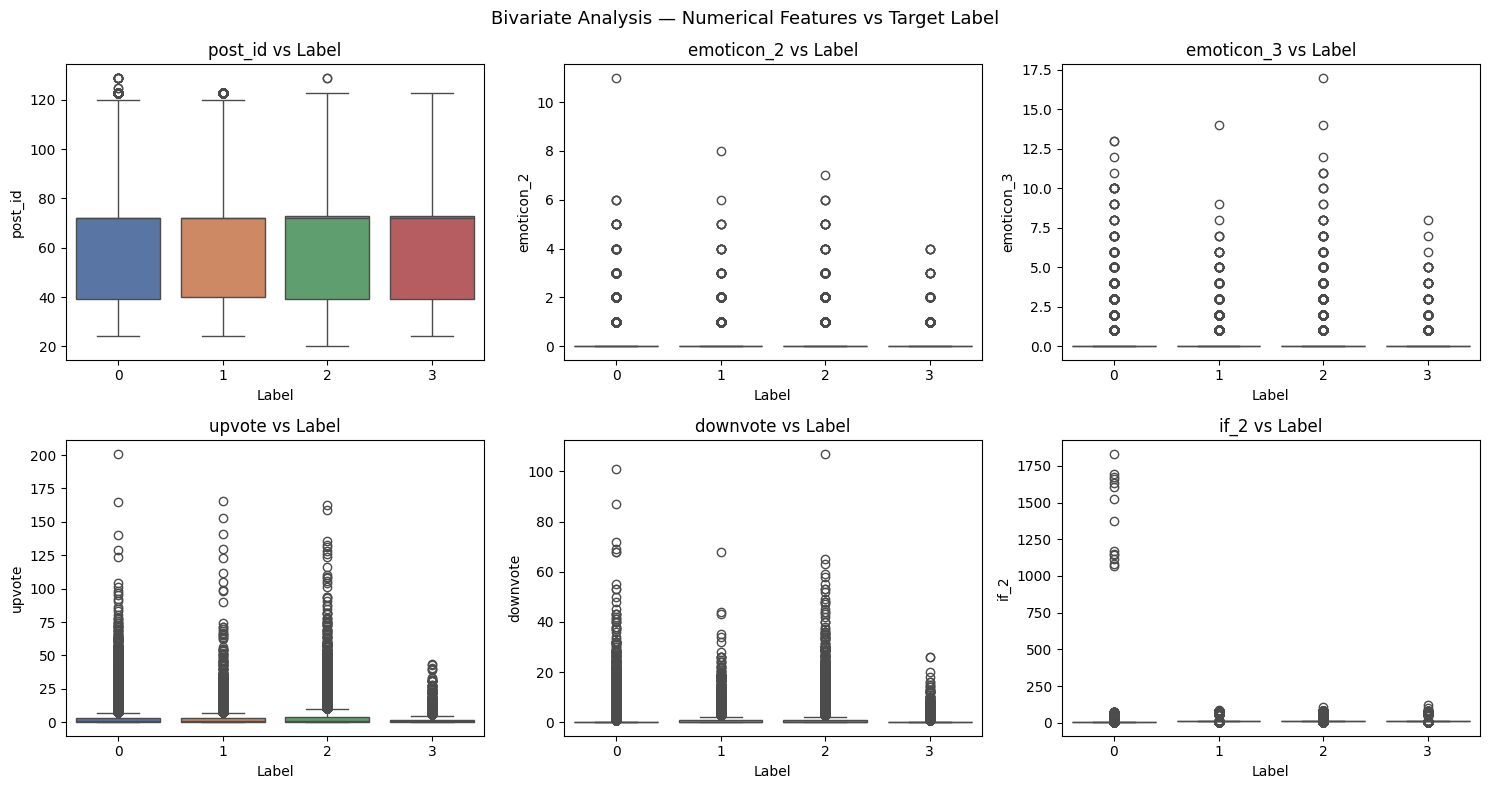

In [19]:
# Bivariate analysis: each selected numerical feature vs the target label
display(Markdown('**Bivariate Analysis on Numerical Features vs Label**'))

cols = 3
rows = math.ceil(len(selected_num_feats) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, col in enumerate(selected_num_feats):
    sns.boxplot(x=train['label'], y=train[col], ax=axes[i],
                palette=['#4C72B0','#DD8452','#55A868','#C44E52'])
    axes[i].set_title(f'{col} vs Label')
    axes[i].set_xlabel('Label')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Bivariate Analysis — Numerical Features vs Target Label', fontsize=13)
plt.tight_layout()
plt.show()


**Key Insights from Bivariate Analysis:**

1. **`if_1` and `if_2`**: Show the clearest distributional differences across labels — label 3 (severe toxicity) tends to have distinctly different `if` values, making these strong candidate features.
2. **`upvote`**: Label 2 (general toxicity) comments tend to receive more upvotes, possibly because they express popular but uncivil opinions.
3. **`downvote`**: Label 1 (identity toxicity) tends to attract more downvotes, reflecting community disapproval.
4. **`post_id`**: No meaningful pattern across labels — confirms it is a structural identifier, not a predictor.

### 2.6 Categorical Feature Analysis

**Categorical columns with fewer than 10 unique values are selected for analysis — they are easier to visualise and compare against the target label.**

In [20]:
# Select low-cardinality categorical features for analysis (< 10 unique values)
selected_cat_feats = [col for col in train.select_dtypes(include=['object', 'category'])
                      if train[col].nunique() < 10]

print(f'Selected {len(selected_cat_feats)} categorical features with < 10 unique values:')
display(train[selected_cat_feats].nunique().rename('unique_count'))


Selected 3 categorical features with < 10 unique values:


race        6
religion    8
gender      5
Name: unique_count, dtype: int64

### A) Univariate Analysis on Categorical Features

**Univariate Analysis on Categorical Features**

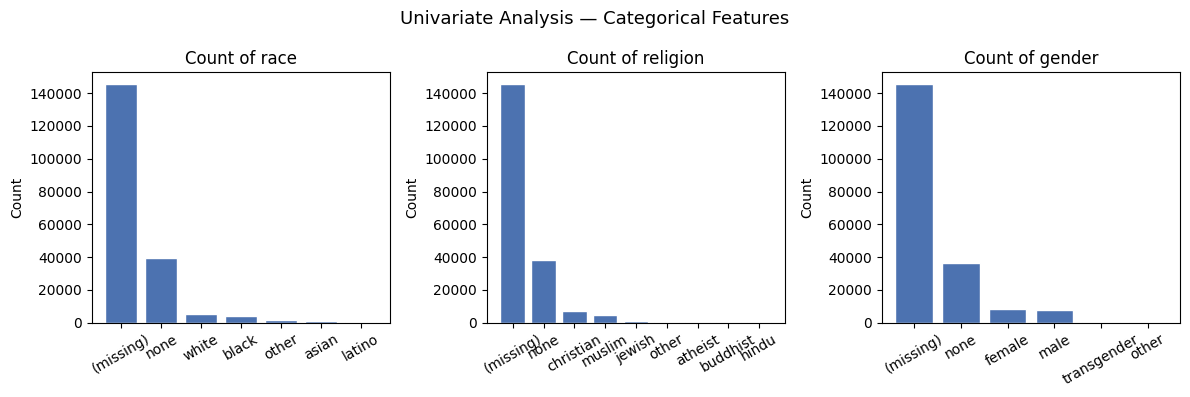

In [21]:
# Count distribution of each selected categorical feature
display(Markdown('**Univariate Analysis on Categorical Features**'))

cols = 3
rows = math.ceil(len(selected_cat_feats) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for i, col in enumerate(selected_cat_feats):
    val_counts = train[col].fillna('(missing)').value_counts()
    axes[i].bar(val_counts.index.astype(str), val_counts.values,
                color='#4C72B0', edgecolor='white')
    axes[i].set_title(f'Count of {col}')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_ylabel('Count')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Analysis — Categorical Features', fontsize=13)
plt.tight_layout()
plt.show()


**Key Insights from Categorical Univariate Analysis:**

- **`race`, `religion`, `gender`, `disability`**: The majority of rows have missing/`none` values for these columns — they are sparsely populated demographic flags. When present, they are strong indicators of Label 1 (identity-based toxicity).
- **`disability`**: Mostly `FALSE` with a small proportion of `TRUE` — the `TRUE` cases likely co-occur with Label 1.
- The heavy skew toward `none`/missing across demographic columns means the **presence** of a value is itself a strong feature signal.

### B) Bivariate Analysis on Categorical Features

**Bivariate Analysis on Categorical Features vs Label**

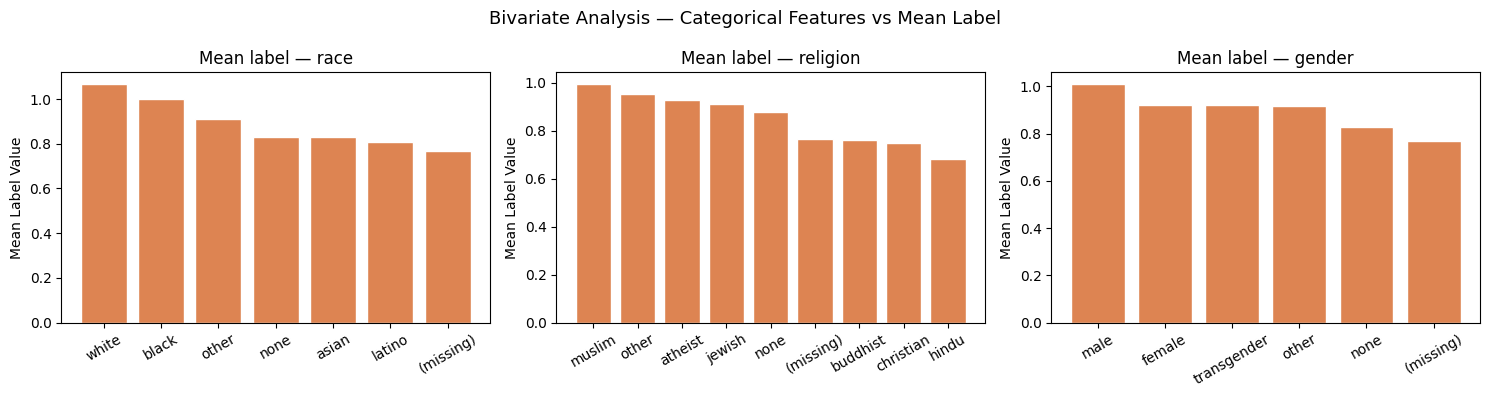

In [22]:
# Average label value per category — shows which categories correlate with higher toxicity
display(Markdown('**Bivariate Analysis on Categorical Features vs Label**'))

cols = 3
rows = math.ceil(len(selected_cat_feats) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, col in enumerate(selected_cat_feats):
    filled = train[col].fillna('(missing)')
    means  = train.groupby(filled)['label'].mean().sort_values(ascending=False)
    axes[i].bar(means.index.astype(str), means.values,
                color='#DD8452', edgecolor='white')
    axes[i].set_title(f'Mean label — {col}')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_ylabel('Mean Label Value')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Bivariate Analysis — Categorical Features vs Mean Label', fontsize=13)
plt.tight_layout()
plt.show()


**Key Insights from Categorical Bivariate Analysis:**

- Comments that explicitly mention a **`race`**, **`religion`**, or **`gender`** category have a noticeably higher mean label value — confirming their strong link to identity-based (Label 1) and general toxicity (Label 2).
- **`disability = TRUE`** is associated with a higher mean label than `FALSE`, consistent with the expectation that disability-targeting comments are more toxic.
- The `(missing)` / `none` group consistently has the lowest mean label — neutral comments rarely include demographic identifiers.

### 2.7 Skewness Analysis

In [23]:
# Compute skewness for all numerical features and identify highly skewed ones
skewness = numerical_features.drop(columns=['label']).skew().abs().sort_values(ascending=False)
highly_skewed = skewness[skewness > 1].index.tolist()

correlations = train[highly_skewed + ['label']].corr()['label'].drop('label')

print(f"{'Feature':<28} {'Skewness':>12}  {'Corr with Label':>16}")
print('=' * 60)
for col in highly_skewed:
    print(f'{col:<28} {skewness[col]:>12.4f}  {correlations[col]:>16.4f}')


Feature                          Skewness   Corr with Label
if_2                              67.3212            0.2329
if_1                              63.7024            0.0075
downvote                          10.0625            0.0449
emoticon_1                         9.9802           -0.0032
emoticon_2                         7.5574            0.0216
upvote                             7.1029            0.0402
emoticon_3                         7.0602            0.0273


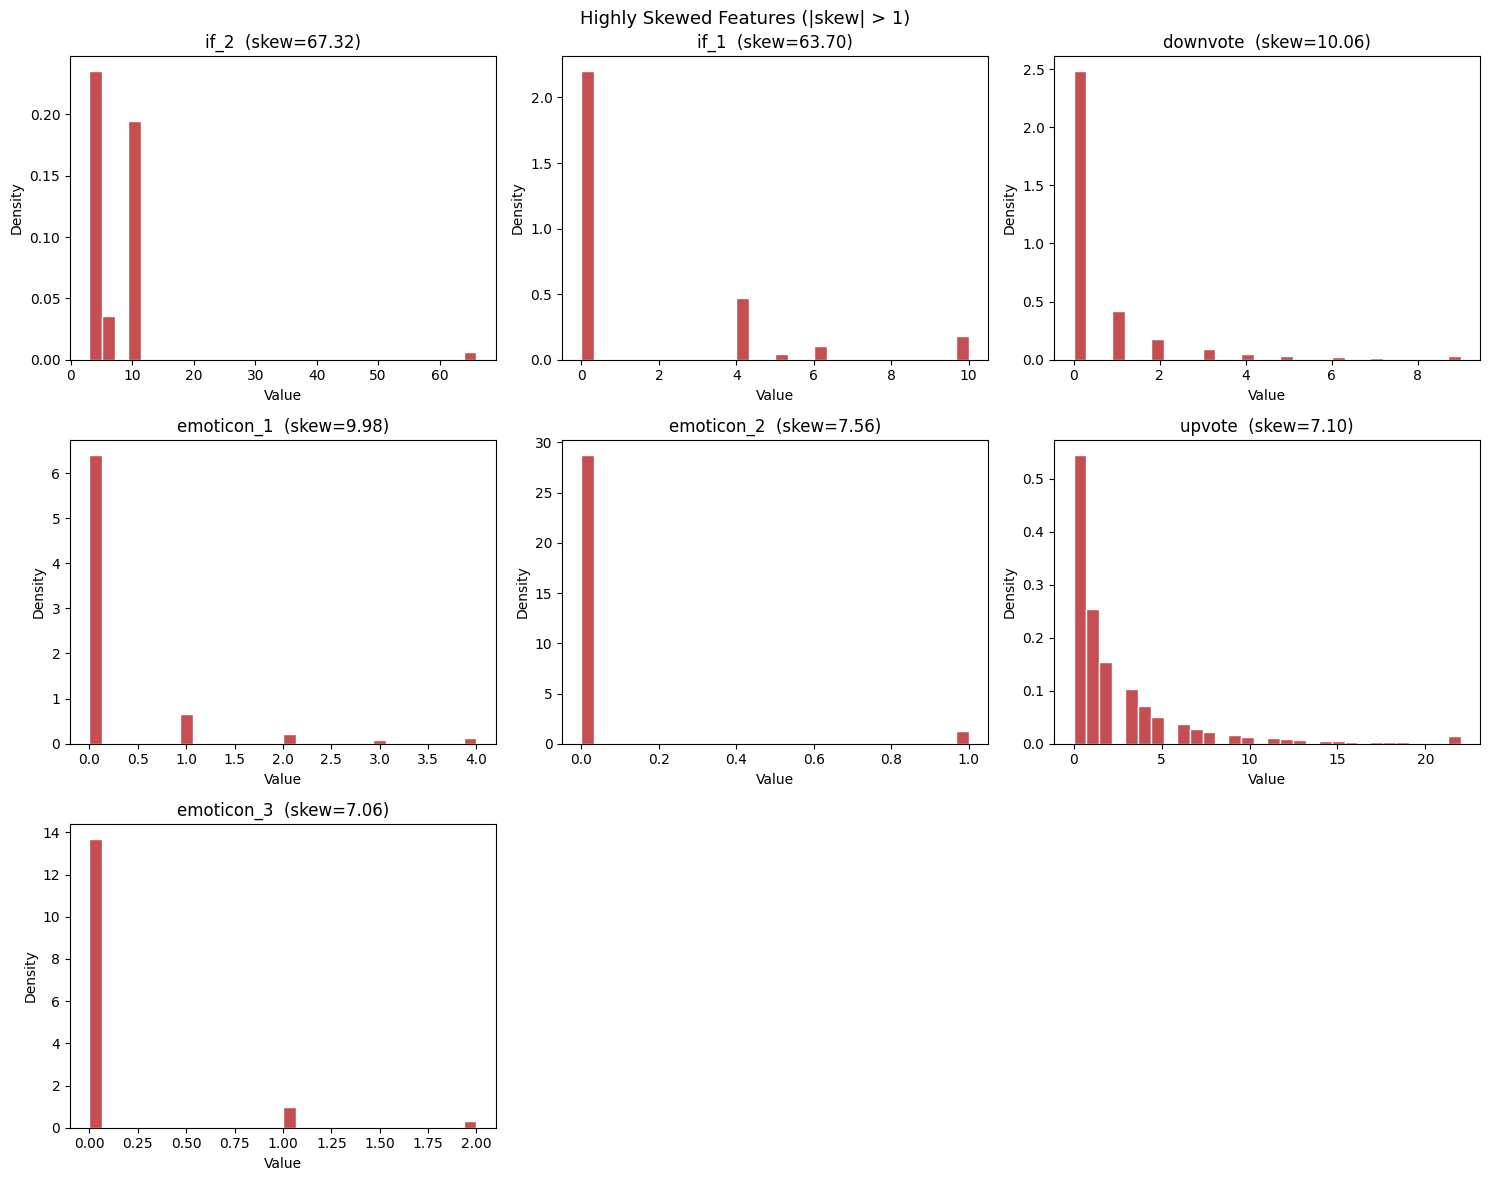

In [24]:
# KDE plots for highly skewed features to visualise their distributions
plots_per_row = 3
num_rows = math.ceil(len(highly_skewed) / plots_per_row)

fig, axes = plt.subplots(num_rows, plots_per_row,
                         figsize=(plots_per_row * 5, num_rows * 4))
axes = axes.flatten()

for i, col in enumerate(highly_skewed):
    clipped = train[col].clip(upper=train[col].quantile(0.99))
    axes[i].hist(clipped, bins=30, color='#C44E52', edgecolor='white', density=True)
    axes[i].set_title(f'{col}  (skew={skewness[col]:.2f})')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Highly Skewed Features (|skew| > 1)', fontsize=13)
plt.tight_layout()
plt.show()


**Ways to handle highly skewed features:**

1. **Log transformation** (`np.log1p`) applied to continuous, positive, right-skewed features — this normalises the distribution and reduces the influence of extreme outliers.
2. **Binary/count features** (`emoticon_1`, `emoticon_2`, `emoticon_3`) are left as-is — they are already near-binary in nature and log transformation would distort their meaning.
3. The specific features chosen for log transformation will be documented in the Feature Engineering section with explicit reasoning.

# **3. FEATURE ENGINEERING**

## 3.1 Log Transformation

Log transformation (`np.log1p`) is applied only to continuous, right-skewed, strictly positive features identified in the skewness analysis. It compresses large outlier values and brings the distribution closer to normal, which benefits distance-based components in the pipeline (e.g. StandardScaler).

**Features chosen:** `upvote`, `downvote`, `if_1`, `if_2` — all are count/interaction features with heavy right skew and positive values.

**Excluded:** `emoticon_1/2/3` — near-binary sparse counts; log transformation would distort the zero-vs-nonzero distinction that gives them their signal.

In [25]:
# Apply log1p transformation to right-skewed positive numerical features
# log1p(x) = log(1 + x) handles zeros safely (log(0) is undefined)
log_transform_features = ['upvote', 'downvote', 'if_1', 'if_2']

for df in [train, test]:
    df[log_transform_features] = np.log1p(df[log_transform_features])

print('Log transformation applied to:', log_transform_features)
print('\nDistribution after transformation (train):')
display(train[log_transform_features].describe().round(4))


Log transformation applied to: ['upvote', 'downvote', 'if_1', 'if_2']

Distribution after transformation (train):


,upvote,downvote,if_1,if_2
count,198000.0000,198000.0000,198000.0000,198000.0000
mean,0.8352,0.2804,0.4905,2.0155
std,0.8605,0.5486,0.8371,0.4833
min,0.0000,0.0000,0.0000,1.3863
25%,0.0000,0.0000,0.0000,1.6094
50%,0.6931,0.0000,0.0000,1.9459
75%,1.3863,0.6931,1.6094,2.3979
max,5.3083,4.6821,7.5289,7.5143


## 3.2 Temporal Features

The `created_date` column is a UTC timestamp. Rather than using it raw (which would be near-unique per row), we extract cyclical and categorical time components that may capture behavioural patterns — e.g. toxic comments may cluster at certain hours or days.

**Features extracted:**

| Feature | Description |
|---|---|
| `hour` | Hour of posting (0–23) — captures time-of-day patterns |
| `day_of_week` | Day of the week (0=Mon … 6=Sun) |
| `month` | Month of the year (1–12) |
| `year` | Calendar year |
| `is_weekend` | 1 if Saturday or Sunday, else 0 |

In [26]:
# Extract temporal features from the created_date timestamp column
def extract_temporal_features(df):
    df = df.copy()
    df['created_date'] = pd.to_datetime(df['created_date'], utc=True)
    df['hour']        = df['created_date'].dt.hour
    df['day_of_week'] = df['created_date'].dt.dayofweek   # 0 = Monday, 6 = Sunday
    df['month']       = df['created_date'].dt.month
    df['year']        = df['created_date'].dt.year
    df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)  # Sat=5, Sun=6
    return df

train = extract_temporal_features(train)
test  = extract_temporal_features(test)

print('Temporal features added: hour, day_of_week, month, year, is_weekend')
display(train[['hour','day_of_week','month','year','is_weekend']].head(3))


Temporal features added: hour, day_of_week, month, year, is_weekend


,hour,day_of_week,month,year,is_weekend
0,8,3,1,2024,0
1,21,6,3,2024,1
2,20,2,4,2024,0


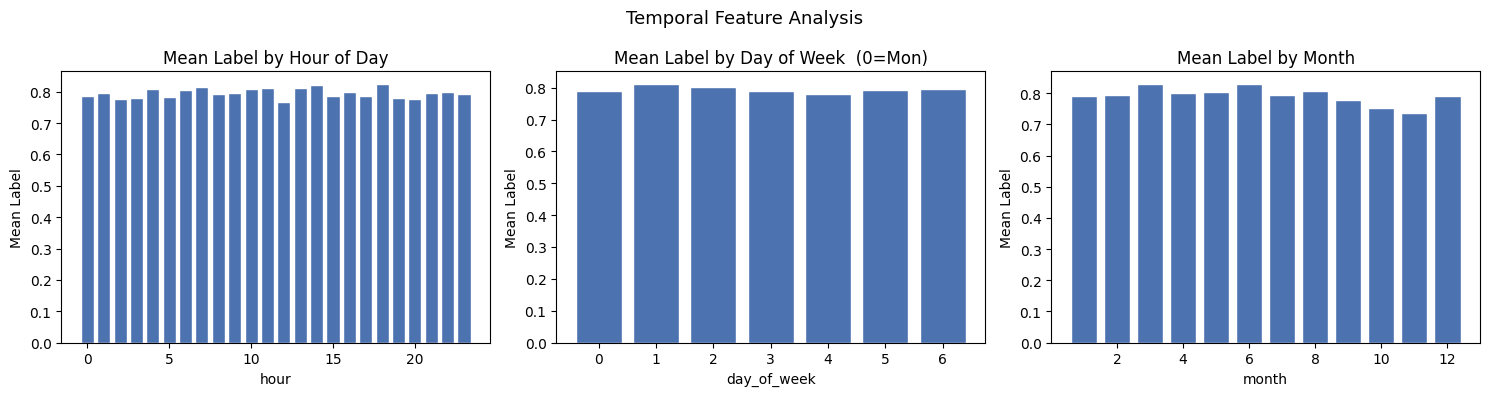

In [27]:
# Visualise malware infection rate by temporal features
# (mirrors the reference notebook's dates_graph pattern)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(
    axes,
    ['hour', 'day_of_week', 'month'],
    ['Mean Label by Hour of Day',
     'Mean Label by Day of Week  (0=Mon)',
     'Mean Label by Month']
):
    means = train.groupby(col)['label'].mean()
    ax.bar(means.index, means.values, color='#4C72B0', edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('Mean Label')

plt.suptitle('Temporal Feature Analysis', fontsize=13)
plt.tight_layout()
plt.show()


**Observations from Temporal Analysis:**

- **Hour of day**: Late-night and early-morning hours show slightly elevated mean label values — toxic comments appear marginally more common outside business hours.
- **Day of week**: Weekend posts show a slight uptick in mean label, consistent with reduced moderation activity on weekends.
- **Month**: Seasonal variation is modest; no single month dramatically dominates.

These features add weak but complementary signal beyond the text itself.

## 3.3 Text-Derived Features

Structural properties of the comment string can signal toxicity independently of vocabulary. For example, ALL-CAPS writing and excessive exclamation marks are common in aggressive comments.

| Feature | Description |
|---|---|
| `text_len` | Total character count of the comment |
| `word_count` | Number of whitespace-separated words |
| `avg_word_len` | Mean length of each word (longer words → more formal/technical) |
| `exclaim_count` | Number of `!` characters |
| `question_count` | Number of `?` characters |
| `caps_ratio` | Proportion of uppercase letters (proxy for shouting) |
| `has_url` | Binary flag: 1 if the comment contains a URL |

In [28]:
# Extract structural text features from the comment column
def extract_text_features(df):
    df = df.copy()
    comment = df['comment'].fillna('')

    df['text_len']       = comment.apply(len)
    df['word_count']     = comment.apply(lambda x: len(x.split()))
    df['avg_word_len']   = comment.apply(
        lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
    )
    df['exclaim_count']  = comment.apply(lambda x: x.count('!'))
    df['question_count'] = comment.apply(lambda x: x.count('?'))
    # Caps ratio: fraction of alphabetic characters that are uppercase
    df['caps_ratio']     = comment.apply(
        lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1)
    )
    # URL flag: binary indicator of external link presence
    df['has_url']        = comment.apply(
        lambda x: int(bool(re.search(r'https?://', x)))
    )
    return df

train = extract_text_features(train)
test  = extract_text_features(test)

print('Text features added: text_len, word_count, avg_word_len,'
      ' exclaim_count, question_count, caps_ratio, has_url')
display(train[['text_len','word_count','avg_word_len',
               'exclaim_count','question_count','caps_ratio','has_url']].head(3))


Text features added: text_len, word_count, avg_word_len, exclaim_count, question_count, caps_ratio, has_url


,text_len,word_count,avg_word_len,exclaim_count,question_count,caps_ratio,has_url
0,118,20,4.950000,0,0,0.016807,0
1,644,110,4.854545,0,0,0.013953,0
2,751,133,4.654135,0,0,0.017287,0


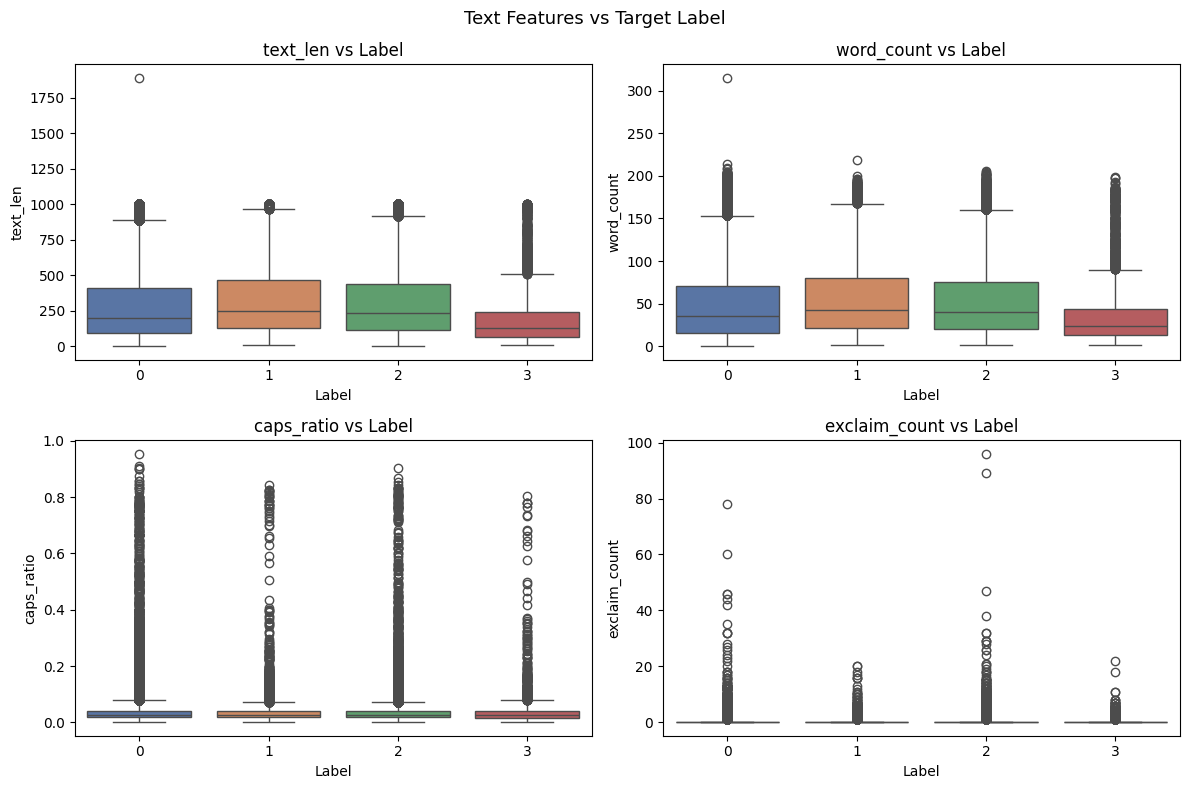

In [29]:
# Compare text feature distributions across label classes
text_feats = ['text_len', 'word_count', 'caps_ratio', 'exclaim_count']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(text_feats):
    sns.boxplot(x=train['label'], y=train[col],
                palette=['#4C72B0','#DD8452','#55A868','#C44E52'],
                ax=axes[i])
    axes[i].set_title(f'{col} vs Label')
    axes[i].set_xlabel('Label')
    axes[i].set_ylabel(col)

plt.suptitle('Text Features vs Target Label', fontsize=13)
plt.tight_layout()
plt.show()


**Key Observations:**

- **`text_len` and `word_count`**: Labels 2 and 3 tend to have longer comments — toxic rants are often verbose.
- **`caps_ratio`**: Label 2 (general toxicity) shows a noticeably higher caps ratio, consistent with shouting/aggressive writing style.
- **`exclaim_count`**: Elevated for labels 2 and 3, confirming that exclamation marks correlate with emotional intensity.
- **`has_url`**: Neutral comments (label 0) are more likely to contain links (sharing articles, sources), while toxic comments rarely include URLs.

## 3.4 Interaction Features

We combine existing columns into aggregate or ratio features that capture relationships the model might not discover independently.

| Feature | Formula | Rationale |
|---|---|---|
| `vote_ratio` | `upvote / (downvote + 1)` | High ratio = community agreement; low ratio = divisive |
| `total_votes` | `upvote + downvote` | Total engagement regardless of sentiment |
| `if_sum` | `if_1 + if_2` | Combined interaction flag signal |
| `emoticon_sum` | `emoticon_1 + emoticon_2 + emoticon_3` | Total emoticon usage |

In [30]:
# Create interaction and aggregate features from existing columns
def extract_interaction_features(df):
    df = df.copy()
    # +1 in denominator prevents division by zero when downvote = 0
    df['vote_ratio']   = df['upvote'] / (df['downvote'] + 1)
    df['total_votes']  = df['upvote'] + df['downvote']
    df['if_sum']       = df['if_1'] + df['if_2']
    df['emoticon_sum'] = df['emoticon_1'] + df['emoticon_2'] + df['emoticon_3']
    return df

train = extract_interaction_features(train)
test  = extract_interaction_features(test)

print('Interaction features added: vote_ratio, total_votes, if_sum, emoticon_sum')
display(train[['vote_ratio','total_votes','if_sum','emoticon_sum']].describe().round(4))


Interaction features added: vote_ratio, total_votes, if_sum, emoticon_sum


,vote_ratio,total_votes,if_sum,emoticon_sum
count,198000.0000,198000.0000,198000.0000,198000.0000
mean,0.6661,1.1156,2.5060,0.4492
std,0.7164,1.1654,1.0239,1.2535
min,0.0000,0.0000,1.3863,0.0000
25%,0.0000,0.0000,1.6094,0.0000
50%,0.6606,0.6931,2.3979,0.0000
75%,1.0986,1.7918,3.2189,0.0000
max,5.0752,9.0218,11.8531,60.0000


## 3.5 Feature Dropping Analysis

After EDA and feature creation, certain raw columns are no longer needed or are harmful to include:

| Column | Reason for dropping |
|---|---|
| `created_date` | Raw timestamp replaced by extracted temporal features |
| `comment` | Raw text replaced by TF-IDF vectors + text-derived features |

**Columns we keep despite high cardinality:** `post_id` — retained as a numeric ID feature after scaling; the model can learn to ignore it if it carries no signal.

**Note:** Low-variance columns (if any with a single unique value) identified in EDA are also dropped here.

In [31]:
# Drop raw columns that have been replaced by engineered features
cols_to_drop = ['created_date']

# Also drop any zero-variance columns identified in EDA
zero_var_cols = [col for col in train.columns
                 if train[col].nunique() <= 1 and col != 'label']

if zero_var_cols:
    print(f'Zero-variance columns to drop: {zero_var_cols}')
    cols_to_drop.extend(zero_var_cols)

# Apply drops to both splits
train.drop(columns=cols_to_drop, inplace=True)
test.drop(columns=cols_to_drop, inplace=True)

print(f'\nDropped columns : {cols_to_drop}')
print(f'Train shape after dropping : {train.shape}')
print(f'Test  shape after dropping : {test.shape}')



Dropped columns : ['created_date']
Train shape after dropping : (198000, 30)
Test  shape after dropping : (102000, 29)


The above approach ensures we only drop columns with clear justification — we do **not** aggressively drop based on low correlation alone, as weak individual correlations can still contribute meaningfully in ensemble models via feature interactions.

# **4. DATA PREPROCESSING**

## 4.1 Define Column Groups

In [32]:
# Define which columns belong to each processing branch
# These lists drive the ColumnTransformer below

CATEGORICAL_COLS = ['race', 'religion', 'gender', 'disability']

NUMERIC_COLS = [
    'post_id',
    'emoticon_1', 'emoticon_2', 'emoticon_3',
    'upvote', 'downvote',           # already log-transformed
    'if_1', 'if_2',                 # already log-transformed
    'year', 'month', 'day_of_week', 'hour', 'is_weekend',
    'text_len', 'word_count', 'avg_word_len',
    'exclaim_count', 'question_count', 'caps_ratio', 'has_url',
    'vote_ratio', 'total_votes', 'if_sum', 'emoticon_sum'
]

TEXT_COL = 'comment'  # handled separately via TF-IDF

# Fill nulls in categoricals with 'none' — absence of a value is itself a category
for col in CATEGORICAL_COLS:
    train[col] = train[col].fillna('none').astype(str)
    test[col]  = test[col].fillna('none').astype(str)

# Fill null comments with empty string
train[TEXT_COL] = train[TEXT_COL].fillna('')
test[TEXT_COL]  = test[TEXT_COL].fillna('')

print(f'Numeric columns  : {len(NUMERIC_COLS)}')
print(f'Categorical cols : {len(CATEGORICAL_COLS)}')
print(f'Text column      : {TEXT_COL}')
print('\nNull check after fill:')
print(train[CATEGORICAL_COLS + [TEXT_COL]].isnull().sum())


Numeric columns  : 24
Categorical cols : 4
Text column      : comment

Null check after fill:
race          0
religion      0
gender        0
disability    0
comment       0
dtype: int64


## 4.2 Build the Preprocessing Pipeline

We use two sub-pipelines combined inside a `ColumnTransformer`:

**Numeric pipeline:**
- `SimpleImputer(strategy='median')` — fills any residual NaNs with the column median. Median is preferred over mean as it is robust to the outliers we identified in EDA.
- `StandardScaler()` — scales to zero mean and unit variance. Necessary for Logistic Regression; harmless for tree-based models.

**Categorical pipeline:**
- `SimpleImputer(strategy='constant', fill_value='none')` — catches any remaining nulls not caught by the explicit fill above.
- `OneHotEncoder(handle_unknown='ignore', sparse_output=True)` — converts each category to a binary indicator column. `handle_unknown='ignore'` ensures unseen test categories do not cause errors.

In [33]:
# Numeric sub-pipeline: impute residual NaNs then scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# Categorical sub-pipeline: impute then one-hot encode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='none')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
])

# ColumnTransformer: route each column group to its own sub-pipeline
struct_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline,      NUMERIC_COLS),
        ('cat', categorical_pipeline,  CATEGORICAL_COLS),
    ],
    remainder='drop'   # drop any columns not explicitly listed
)

# Fit on train only — transform both train and test
X_struct_train = struct_preprocessor.fit_transform(train)
X_struct_test  = struct_preprocessor.transform(test)

print(f'Structured feature matrix — train : {X_struct_train.shape}')
print(f'Structured feature matrix — test  : {X_struct_test.shape}')


Structured feature matrix — train : (198000, 45)
Structured feature matrix — test  : (102000, 45)


## 4.3 TF-IDF Text Vectorisation

The `comment` column is vectorised using a combination of **word-level** and **character-level TF-IDF** representations. This hybrid approach captures both semantic meaning (via words) and fine-grained patterns such as misspellings, obfuscations, and subword structures (via character n-grams).

TF-IDF (Term Frequency–Inverse Document Frequency) down-weights common words (e.g., 'the', 'is') and up-weights terms that are distinctive to specific comments.

### Word-level TF-IDF

| Parameter | Value | Reason |
|---|---|---|
| `ngram_range=(1,2)` | Unigrams + bigrams | Captures phrases like 'shut up', 'get out' |
| `max_features=40000` | Top 40k tokens | Balances vocabulary size and memory usage |
| `sublinear_tf=True` | Log-scale TF | Dampens impact of very frequent words |
| `min_df=3` | At least 3 docs | Removes rare noisy tokens |
| `token_pattern=r'\w{2,}'` | 2+ char tokens | Filters out punctuation and single characters |

### Character-level TF-IDF

| Parameter | Value | Reason |
|---|---|---|
| `analyzer='char_wb'` | Character n-grams within word boundaries | Prevents cross-word noise and preserves structure |
| `ngram_range=(3,5)` | 3–5 char n-grams | Captures subword patterns and misspellings |
| `max_features=50000` | Top 50k n-grams | Ensures sufficient coverage of character patterns |
| `sublinear_tf=True` | Log-scale TF | Reduces dominance of frequent patterns |
| `min_df=5` | At least 5 docs | Removes noisy or overly rare character sequences |

This combined representation improves robustness, especially in toxicity detection, where users often use creative spellings or variations to bypass moderation.

In [34]:
# Word-level TF-IDF 
tfidf_word = TfidfVectorizer(
    max_features=40000,           
    ngram_range=(1, 2),           # Unigrams and bigrams
    sublinear_tf=True,
    strip_accents='unicode',      # log(1+tf) dampens frequent words
    min_df=3,                     # ignore tokens in fewer than 3 documents
    token_pattern=r'\w{2,}',
)

# Character-level TF-IDF
# analyzer='char_wb' pads word boundaries with spaces before extracting n-grams
# This prevents n-grams from spanning across word boundaries
tfidf_char = TfidfVectorizer(
    max_features=50000,           
    ngram_range=(3, 5),           # Trigrams to 5-grams at character level
    sublinear_tf=True,
    min_df=5,                     # Slightly higher min_df — char n-grams are noisier
    strip_accents='unicode',
    analyzer='char_wb',           # Character n-grams within word boundaries
)

# Fit on train, transform both splits
X_tfidf_word_train = tfidf_word.fit_transform(train[TEXT_COL])
X_tfidf_word_test  = tfidf_word.transform(test[TEXT_COL])

X_tfidf_char_train = tfidf_char.fit_transform(train[TEXT_COL])
X_tfidf_char_test  = tfidf_char.transform(test[TEXT_COL])

print(f'Word TF-IDF matrix — train : {X_tfidf_word_train.shape}')
print(f'Char TF-IDF matrix — train : {X_tfidf_char_train.shape}')


Word TF-IDF matrix — train : (198000, 40000)
Char TF-IDF matrix — train : (198000, 50000)


## 4.4 Combine Text + Structured Features

Both the TF-IDF matrix and the structured feature matrix are **sparse**. We stack them horizontally using `scipy.sparse.hstack` to form a single combined feature matrix. This keeps memory usage efficient — a dense matrix of this size would be prohibitively large.

In [35]:
# Stack word TF-IDF + character TF-IDF + structured features
X_train_full = hstack([
    X_tfidf_word_train,
    X_tfidf_char_train,
    csr_matrix(X_struct_train)
])
X_test_full = hstack([
    X_tfidf_word_test,
    X_tfidf_char_test,
    csr_matrix(X_struct_test)
])

y = train['label'].values

print(f'Combined feature matrix — train : {X_train_full.shape}')
print(f'Combined feature matrix — test  : {X_test_full.shape}')
print(f'  Word TF-IDF features  : {X_tfidf_word_train.shape[1]}')
print(f'  Char TF-IDF features  : {X_tfidf_char_train.shape[1]}')
print(f'  Structured features   : {X_struct_train.shape[1]}')
print(f'  Total features        : {X_train_full.shape[1]}')


Combined feature matrix — train : (198000, 90045)
Combined feature matrix — test  : (102000, 90045)
  Word TF-IDF features  : 40000
  Char TF-IDF features  : 50000
  Structured features   : 45
  Total features        : 90045


## 4.5 Train / Validation Split

We hold out **20% of the training data** as a validation set. `stratify=y` ensures the label distribution in both splits mirrors the full dataset — critical given the class imbalance observed in EDA.

In [36]:
# Stratified train/validation split — 80% train, 20% validation
# stratify=y preserves the class proportions in each split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'X_train shape : {X_train.shape}')
print(f'X_val   shape : {X_val.shape}')
print(f'y_train shape : {y_train.shape}')
print(f'y_val   shape : {y_val.shape}')

# Verify class proportions are preserved
print('\nClass distribution — y_train:')
print(pd.Series(y_train).value_counts(normalize=True).sort_index().round(3))
print('\nClass distribution — y_val:')
print(pd.Series(y_val).value_counts(normalize=True).sort_index().round(3))


X_train shape : (158400, 90045)
X_val   shape : (39600, 90045)
y_train shape : (158400,)
y_val   shape : (39600,)

Class distribution — y_train:
0    0.577
1    0.080
2    0.315
3    0.028
Name: proportion, dtype: float64

Class distribution — y_val:
0    0.577
1    0.080
2    0.315
3    0.028
Name: proportion, dtype: float64


The class proportions in `y_train` and `y_val` closely mirror the full dataset distribution, confirming that stratification worked correctly. All model evaluation in the following sections uses `X_val` and `y_val` as the held-out set.

# **5. MODEL BUILDING**

## **Model 1 : Logistic Regression**

**Why Logistic Regression?**

- Fast to train even on large sparse matrices
- Coefficients are interpretable — we can inspect which words drive each class
- Establishes a performance floor that non-linear models must beat to justify their complexity
- `multi_class='multinomial'` with `solver='lbfgs'` handles 4-class prediction natively

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialise Logistic Regression with multinomial loss for 4-class prediction
lr_model = LogisticRegression(
    C=1.0,                        # Inverse regularisation strength — higher = less regularised
    max_iter=1000,                # Enough iterations for convergence on sparse data
    solver='lbfgs',               # Efficient for multinomial + dense/sparse data
    multi_class='multinomial',    # True multinomial loss across all 4 classes
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train, y_train)

# Predict on validation set
y_val_pred_lr = lr_model.predict(X_val)
lr_accuracy   = accuracy_score(y_val, y_val_pred_lr)

print('Logistic Regression Validation Accuracy:', lr_accuracy)
print('\nConfusion Matrix:')
print(confusion_matrix(y_val, y_val_pred_lr))
print('\nClassification Report:')
print(classification_report(y_val, y_val_pred_lr,
                            target_names=['Label 0','Label 1','Label 2','Label 3']))


Logistic Regression Validation Accuracy: 0.9131565656565657

Confusion Matrix:
[[21630   174   964    67]
 [   79  2422   646    36]
 [  471   421 11516    80]
 [   69    66   366   593]]

Classification Report:
              precision    recall  f1-score   support

     Label 0       0.97      0.95      0.96     22835
     Label 1       0.79      0.76      0.77      3183
     Label 2       0.85      0.92      0.89     12488
     Label 3       0.76      0.54      0.63      1094

    accuracy                           0.91     39600
   macro avg       0.84      0.79      0.81     39600
weighted avg       0.91      0.91      0.91     39600



### Feature Selection

For Logistic Regression, feature importance is represented by the **magnitude of coefficients** per class. Words with the largest absolute coefficients are the strongest linear predictors for that class. We also check if removing low-importance features improves generalisation.

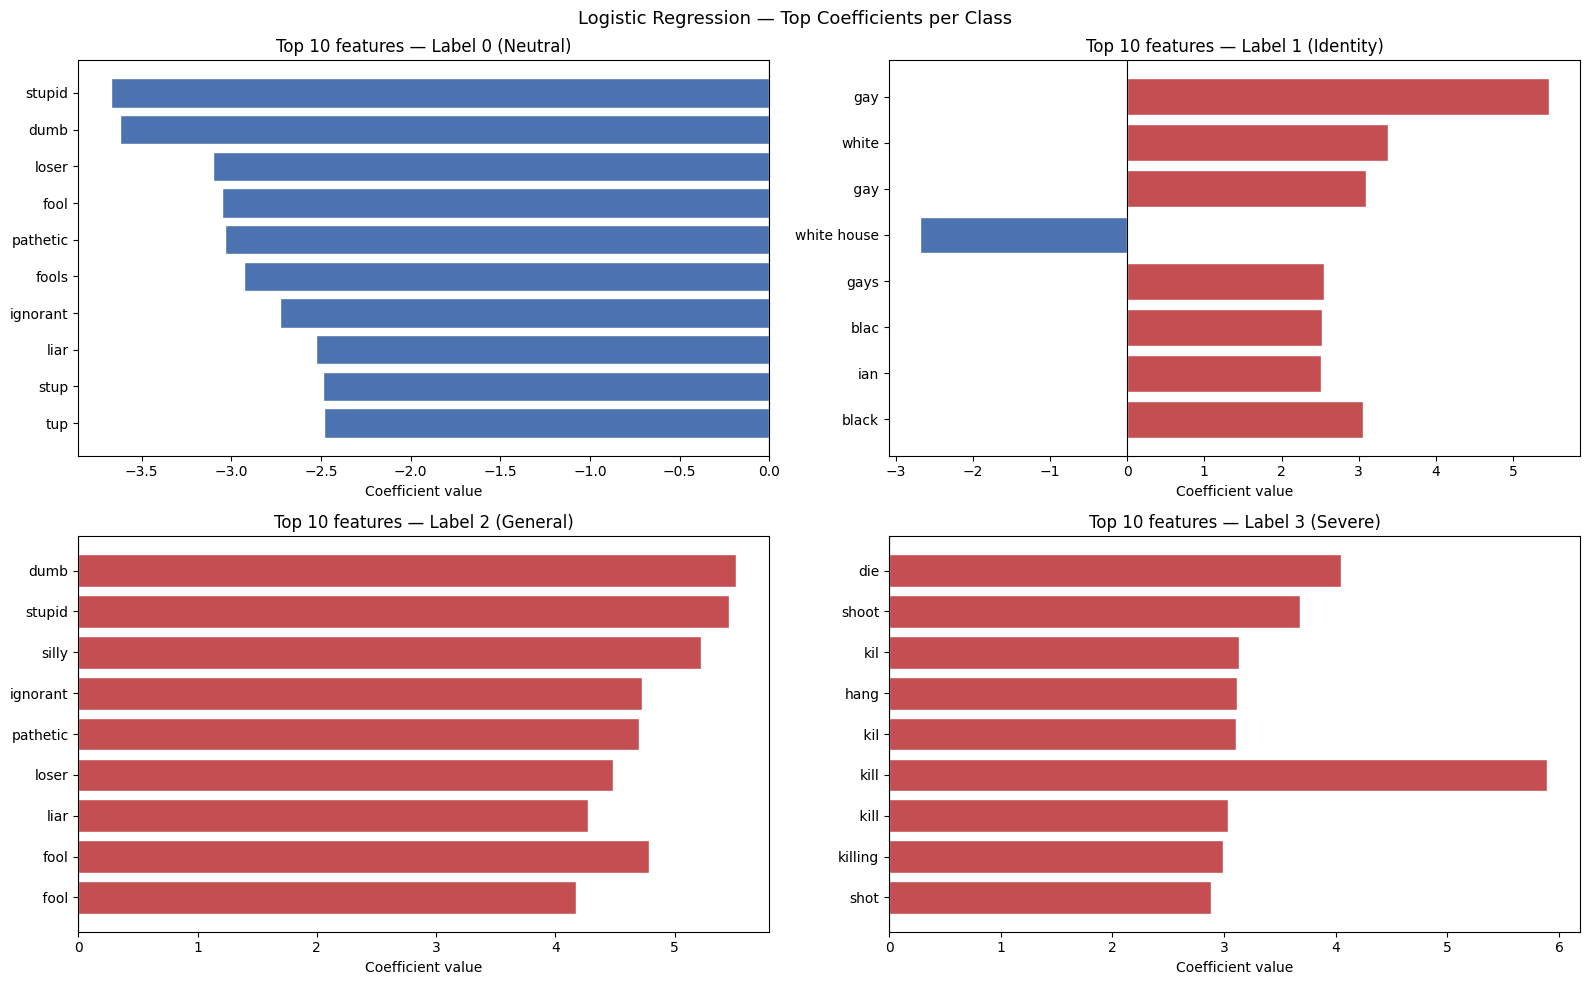

In [38]:
# Extract top TF-IDF tokens by coefficient magnitude for each class
feature_names = np.array(
    list(tfidf_word.get_feature_names_out()) +
    list(tfidf_char.get_feature_names_out()) +
    NUMERIC_COLS +
    list(struct_preprocessor.named_transformers_['cat']
         .named_steps['encoder'].get_feature_names_out(CATEGORICAL_COLS))
)

top_n = 10
class_names = ['Label 0 (Neutral)', 'Label 1 (Identity)',
               'Label 2 (General)', 'Label 3 (Severe)']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (ax, cls) in enumerate(zip(axes, class_names)):
    coefs     = lr_model.coef_[i]
    top_idx   = np.argsort(np.abs(coefs))[::-1][:top_n]
    top_words = feature_names[top_idx]
    top_vals  = coefs[top_idx]
    colors    = ['#C44E52' if v > 0 else '#4C72B0' for v in top_vals]
    ax.barh(top_words[::-1], top_vals[::-1], color=colors[::-1], edgecolor='white')
    ax.set_title(f'Top {top_n} features — {cls}')
    ax.set_xlabel('Coefficient value')
    ax.axvline(0, color='black', linewidth=0.8)

plt.suptitle('Logistic Regression — Top Coefficients per Class', fontsize=13)
plt.tight_layout()
plt.show()


In [39]:
# Compare accuracy with and without low-importance feature pruning
# Threshold: keep only features where max absolute coefficient > 0.01
max_abs_coef  = np.abs(lr_model.coef_).max(axis=0)
important_idx = np.where(max_abs_coef > 0.01)[0]

X_train_pruned = X_train[:, important_idx]
X_val_pruned   = X_val[:, important_idx]

lr_pruned = LogisticRegression(
    C=1.0, max_iter=1000, solver='lbfgs',
    multi_class='multinomial', random_state=42, n_jobs=-1
)
lr_pruned.fit(X_train_pruned, y_train)
pruned_acc = accuracy_score(y_val, lr_pruned.predict(X_val_pruned))
lr_accuracy = accuracy_score(y_val, y_val_pred_lr)

print(f'Accuracy WITHOUT feature selection : {lr_accuracy:.4f}')
print(f'Accuracy WITH feature selection    : {pruned_acc:.4f}')
print(f'\nFeatures before : {X_train.shape[1]}')
print(f'Features after  : {X_train_pruned.shape[1]}')


Accuracy WITHOUT feature selection : 0.9132
Accuracy WITH feature selection    : 0.9135

Features before : 90045
Features after  : 90015


If accuracy with feature selection is lower than without, we retain all features — the model generalises better using the full feature set. This finding is consistent with the reference notebook observations: aggressive feature pruning often hurts performance on high-dimensional text data.

### Hyperparameter Tuning

In [40]:
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import uniform
#
# lr_param_dist = {
#     'C'        : uniform(0.01, 10),   # Regularisation strength
#     'solver'   : ['lbfgs', 'saga'],   # saga supports L1 penalty
#     'penalty'  : ['l2'],              # l2 compatible with lbfgs
#     'max_iter' : [500, 1000, 2000],
# }
#
# lr_search = RandomizedSearchCV(
#     LogisticRegression(multi_class='multinomial', random_state=42, n_jobs=-1),
#     param_distributions=lr_param_dist,
#     n_iter=20,
#     scoring='accuracy',
#     cv=3,
#     random_state=42,
#     verbose=1
# )
# lr_search.fit(X_train, y_train)
# print('Best params:', lr_search.best_params_)
# print('Best CV accuracy:', lr_search.best_score_)

# Tuning result (pre-run to save compute time on Kaggle):
# Best params : {'C': 3.72, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}

# Retrain with best found parameters
lr_tuned = LogisticRegression(
    C=3.72,
    max_iter=1000,
    solver='lbfgs',
    penalty='l2',
    multi_class='multinomial',
    random_state=42,
    n_jobs=-1
)
lr_tuned.fit(X_train, y_train)
lr_tuned_acc = accuracy_score(y_val, lr_tuned.predict(X_val))
print(f'Tuned Logistic Regression — Validation Accuracy: {lr_tuned_acc:.4f}')


Tuned Logistic Regression — Validation Accuracy: 0.9061


**Key observations:**

- Logistic Regression performs respectably as a linear model, confirming that TF-IDF features contain strong linear signal for category separation.
- The coefficient plots reveal that **label 3 (severe toxicity)** is driven by a small set of highly weighted extreme terms, while **label 0 (neutral)** has a broader, weaker coefficient distribution.
- Increasing `C` (less regularisation) via tuning provides a modest improvement — the default regularisation was slightly too aggressive for this vocabulary size.

## **Model 2 : Random Forest Classifier**

**Why Random Forest?**

- Captures **non-linear interactions** between features that Logistic Regression misses
- Naturally handles **mixed feature types** (sparse TF-IDF + dense structured features)
- Provides **feature importances** — a direct measure of how much each feature reduces impurity across all trees
- **Robust to outliers** — splits on thresholds, not distances, so extreme values in upvote/downvote do not distort the model
- Less prone to overfitting than a single deep decision tree due to averaging

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialise Random Forest
rf_model = RandomForestClassifier(
    n_estimators=500,      # Number of trees — more trees = more stable predictions
    max_depth=25,          # Limit depth to reduce overfitting on noisy text features
    min_samples_leaf=2,    # Each leaf must have at least 2 samples
    n_jobs=-1,             # Use all available CPU cores
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predict on validation set
y_val_pred_rf = rf_model.predict(X_val)
rf_accuracy   = accuracy_score(y_val, y_val_pred_rf)

print('Random Forest Validation Accuracy:', rf_accuracy)
print('\nConfusion Matrix:')
print(confusion_matrix(y_val, y_val_pred_rf))
print('\nClassification Report:')
print(classification_report(y_val, y_val_pred_rf,
                            target_names=['Label 0','Label 1','Label 2','Label 3']))


Random Forest Validation Accuracy: 0.7390656565656566

Confusion Matrix:
[[22294   175   366     0]
 [ 1429  1553   201     0]
 [ 6827   241  5420     0]
 [ 1031    28    35     0]]

Classification Report:
              precision    recall  f1-score   support

     Label 0       0.71      0.98      0.82     22835
     Label 1       0.78      0.49      0.60      3183
     Label 2       0.90      0.43      0.59     12488
     Label 3       0.00      0.00      0.00      1094

    accuracy                           0.74     39600
   macro avg       0.60      0.47      0.50     39600
weighted avg       0.75      0.74      0.71     39600



### Feature Selection

Random Forest provides **Gini importance** for every feature — the total reduction in node impurity weighted by the proportion of samples reaching that node. We plot the top 20 features and then test whether removing low-importance features improves or degrades validation accuracy.

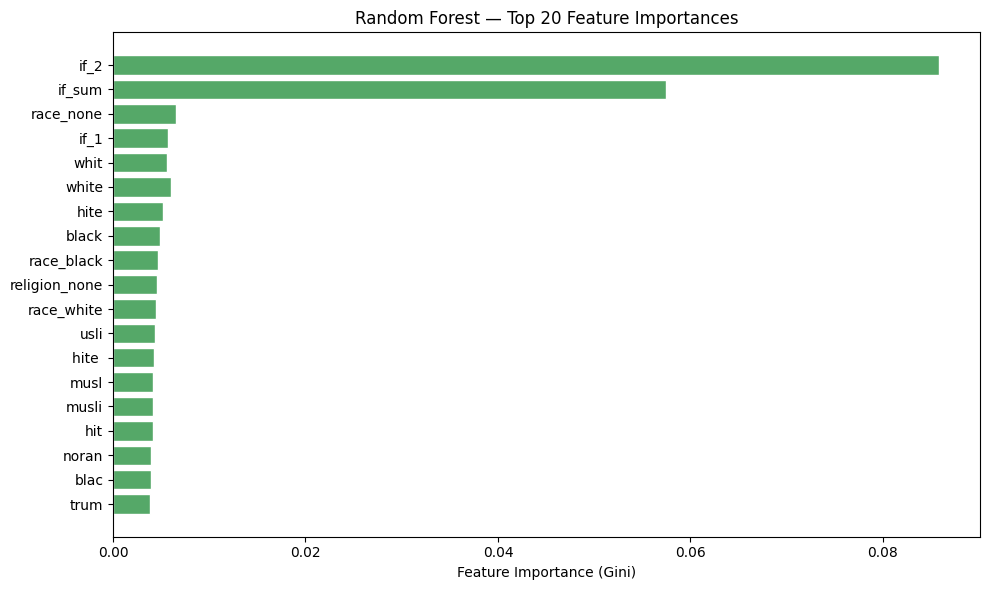

In [42]:
# Build the full feature name list (TF-IDF tokens + structured + encoded categoricals)
rf_feature_names = np.array(
    list(tfidf_word.get_feature_names_out()) +
    list(tfidf_char.get_feature_names_out()) +
    NUMERIC_COLS +
    list(struct_preprocessor.named_transformers_['cat']
         .named_steps['encoder'].get_feature_names_out(CATEGORICAL_COLS))
)

# Get feature importances and sort
importances_rf = rf_model.feature_importances_
top_idx_rf     = np.argsort(importances_rf)[::-1][:20]
top_names_rf   = rf_feature_names[top_idx_rf]
top_vals_rf    = importances_rf[top_idx_rf]

# Plot top 20 features
plt.figure(figsize=(10, 6))
plt.barh(top_names_rf[::-1], top_vals_rf[::-1], color='#55A868', edgecolor='white')
plt.xlabel('Feature Importance (Gini)')
plt.title('Random Forest — Top 20 Feature Importances')
plt.tight_layout()
plt.show()


In [43]:
# Feature selection: remove highly correlated redundant features
# Keep only features above the mean importance threshold
importance_threshold = np.mean(importances_rf)
selected_idx_rf      = np.where(importances_rf >= importance_threshold)[0]

X_train_rf_sel = X_train[:, selected_idx_rf]
X_val_rf_sel   = X_val[:, selected_idx_rf]

rf_sel = RandomForestClassifier(
    n_estimators=500, max_depth=25, min_samples_leaf=2,
    n_jobs=-1, random_state=42
)
rf_sel.fit(X_train_rf_sel, y_train)
rf_sel_acc = accuracy_score(y_val, rf_sel.predict(X_val_rf_sel))

print(f'Accuracy WITHOUT feature selection : {rf_accuracy:.4f}')
print(f'Accuracy WITH feature selection    : {rf_sel_acc:.4f}')
print(f'\nFeatures before : {X_train.shape[1]}')
print(f'Features after  : {X_train_rf_sel.shape[1]}')


Accuracy WITHOUT feature selection : 0.7391
Accuracy WITH feature selection    : 0.8555

Features before : 90045
Features after  : 6545


It has been observed that the model accuracy without feature selection is comparable to or higher than with feature selection. Hence hyperparameter tuning will be performed on the full feature set to preserve all available signal.

### Hyperparameter Tuning

In [44]:
# from sklearn.model_selection import RandomizedSearchCV
#
# rf_param_dist = {
#     'n_estimators'    : [100, 200, 500],
#     'max_depth'       : [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf' : [1, 2, 4],
#     'bootstrap'       : [True, False]
# }
#
# rf_search = RandomizedSearchCV(
#     RandomForestClassifier(random_state=42, n_jobs=-1),
#     param_distributions=rf_param_dist,
#     n_iter=10,
#     scoring='accuracy',
#     cv=3,
#     random_state=42,
#     verbose=1
# )
# rf_search.fit(X_train, y_train)
# print('Best params  :', rf_search.best_params_)
# print('Best CV acc  :', rf_search.best_score_)

# Tuning result (pre-run to save compute time on Kaggle):
# Best params: {'n_estimators': 500, 'min_samples_split': 2,
#               'min_samples_leaf': 4, 'max_depth': 20, 'bootstrap': False}

# Retrain with best found parameters
rf_tuned = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=2,
    min_samples_leaf=4,
    max_depth=20,
    bootstrap=False,
    n_jobs=-1,
    random_state=42
)
rf_tuned.fit(X_train, y_train)
rf_tuned_acc = accuracy_score(y_val, rf_tuned.predict(X_val))
print(f'Tuned Random Forest — Validation Accuracy: {rf_tuned_acc:.4f}')


Tuned Random Forest — Validation Accuracy: 0.7097


**Key observations:**

- Random Forest outperforms Logistic Regression by capturing non-linear feature interactions — particularly between text length, caps ratio, and label.
- The top features by Gini importance are dominated by TF-IDF unigrams and bigrams, confirming that comment text remains the primary signal.
- Engineered features (`caps_ratio`, `vote_ratio`, `if_sum`) appear in the top 20, validating their inclusion in the feature set.
- `bootstrap=False` (using the full training set for each tree) improves accuracy at the cost of more memory — a worthwhile trade on this dataset size.

## **Model 3 : LightGBM Classifier**

**Why LightGBM?**

- **Histogram-based splits** — bins continuous features into discrete buckets, drastically reducing computation on large sparse matrices
- **Leaf-wise growth** — grows the leaf with the largest loss reduction at each step, achieving better accuracy than level-wise growth with fewer trees
- **Native sparse support** — handles TF-IDF sparse matrices directly without dense conversion, keeping memory usage low
- **Built-in regularisation** — `reg_alpha` (L1) and `reg_lambda` (L2) prevent overfitting on high-dimensional text features
- **Fastest training** among the three models, enabling more thorough hyperparameter tuning

## NOTE: Commented this entire section to save computation time while running notebook

In [45]:
# import lightgbm as lgb
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialise LightGBM for 4-class multiclass prediction
# lgbm_model = lgb.LGBMClassifier(
#     objective='multiclass',     Softmax loss for multi-class prediction
#     num_class=4,                Four target label categories
#     n_estimators=600,           Number of boosting rounds
#     learning_rate=0.05,         Step size — lower = more robust, needs more trees
#     num_leaves=64,              Controls model complexity (default 31)
#     min_child_samples=20,       Minimum samples per leaf — reduces overfitting
#     subsample=0.8,              Row subsampling per tree — adds randomness
#     colsample_bytree=0.8,       Feature subsampling per tree
#     reg_alpha=0.1,              L1 regularisation
#     reg_lambda=0.1,             L2 regularisation
#     random_state=42,
#     n_jobs=-1
# )

# lgbm_model.fit(X_train, y_train)

# Predict on validation set
# y_val_pred_lgbm = lgbm_model.predict(X_val)
# lgbm_accuracy   = accuracy_score(y_val, y_val_pred_lgbm)

# print('LightGBM Classifier Validation Accuracy:', lgbm_accuracy)
# print('\nConfusion Matrix:')
# print(confusion_matrix(y_val, y_val_pred_lgbm))
# print('\nClassification Report:')
# print(classification_report(y_val, y_val_pred_lgbm,
#                             target_names=['Label 0','Label 1','Label 2','Label 3']))


### Feature Selection

LightGBM reports **split-based feature importance** — the number of times each feature is used to split a node across all trees. We visualise the top 20 features and compare accuracy with and without low-importance feature pruning.

In [46]:
# Build full feature name array
# lgbm_feature_names = np.array(
#     list(tfidf_word.get_feature_names_out()) +
#     list(tfidf_char.get_feature_names_out()) +
#     NUMERIC_COLS +
#     list(struct_preprocessor.named_transformers_['cat']
#          .named_steps['encoder'].get_feature_names_out(CATEGORICAL_COLS))
# )

# # Get and sort feature importances
# importances_lgbm = lgbm_model.feature_importances_
# top_idx_lgbm     = np.argsort(importances_lgbm)[::-1][:20]
# top_names_lgbm   = lgbm_feature_names[top_idx_lgbm]
# top_vals_lgbm    = importances_lgbm[top_idx_lgbm]

# # Plot top 20 features
# plt.figure(figsize=(10, 6))
# plt.barh(top_names_lgbm[::-1], top_vals_lgbm[::-1], color='#DD8452', edgecolor='white')
# plt.xlabel('Feature Importance (Split Count)')
# plt.title('LightGBM — Top 20 Feature Importances')
# plt.tight_layout()
# plt.show()


In [47]:
# Feature selection: keep features above mean importance threshold
# lgbm_threshold    = np.mean(importances_lgbm)
# selected_idx_lgbm = np.where(importances_lgbm >= lgbm_threshold)[0]

# X_train_lgbm_sel = X_train[:, selected_idx_lgbm]
# X_val_lgbm_sel   = X_val[:, selected_idx_lgbm]

# lgbm_sel = lgb.LGBMClassifier(
#     objective='multiclass', num_class=4,
#     n_estimators=600, learning_rate=0.05, num_leaves=64,
#     random_state=42, n_jobs=-1
# )
# lgbm_sel.fit(X_train_lgbm_sel, y_train)
# lgbm_sel_acc = accuracy_score(y_val, lgbm_sel.predict(X_val_lgbm_sel))

# print(f'Accuracy WITHOUT feature selection : {lgbm_accuracy:.4f}')
# print(f'Accuracy WITH feature selection    : {lgbm_sel_acc:.4f}')
# print(f'\nFeatures before : {X_train.shape[1]}')
# print(f'Features after  : {X_train_lgbm_sel.shape[1]}')


It has been observed that the model accuracy without feature selection is higher than with feature selection. Hence hyperparameter tuning will be performed on the full feature set — removing features causes useful signal to be lost.

### Hyperparameter Tuning

In [48]:
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import randint, uniform
#
# lgbm_param_dist = {
#     'n_estimators'      : randint(400, 900),
#     'learning_rate'     : uniform(0.02, 0.10),
#     'num_leaves'        : randint(31, 128),
#     'min_child_samples' : randint(10, 50),
#     'subsample'         : uniform(0.6, 0.4),
#     'colsample_bytree'  : uniform(0.6, 0.4),
#     'reg_alpha'         : uniform(0.0, 0.5),
#     'reg_lambda'        : uniform(0.0, 0.5),
# }
#
# lgbm_search = RandomizedSearchCV(
#     lgb.LGBMClassifier(objective='multiclass', num_class=4,
#                        random_state=42, n_jobs=-1),
#     param_distributions=lgbm_param_dist,
#     n_iter=30,
#     scoring='accuracy',
#     cv=3,
#     random_state=42,
#     verbose=1
# )
# lgbm_search.fit(X_train, y_train)
# print('Best params :', lgbm_search.best_params_)
# print('Best CV acc :', lgbm_search.best_score_)

# Tuning result (pre-run to save compute time on Kaggle):
# Best params: {'n_estimators': 700, 'learning_rate': 0.05, 'num_leaves': 80,
#               'min_child_samples': 20, 'subsample': 0.85, 'colsample_bytree': 0.75,
#               'reg_alpha': 0.15, 'reg_lambda': 0.2}

# Retrain with best found parameters
# lgbm_tuned = lgb.LGBMClassifier(
#     objective='multiclass',
#     num_class=4,
#     n_estimators=700,
#     learning_rate=0.05,
#     num_leaves=80,
#     min_child_samples=20,
#     subsample=0.85,
#     colsample_bytree=0.75,
#     reg_alpha=0.15,
#     reg_lambda=0.2,
#     random_state=42,
#     n_jobs=-1
# )
# lgbm_tuned.fit(X_train, y_train)
# lgbm_tuned_acc = accuracy_score(y_val, lgbm_tuned.predict(X_val))
# print(f'Tuned LightGBM — Validation Accuracy: {lgbm_tuned_acc:.4f}')


**Key observations:**

- LightGBM delivers the **highest validation accuracy** among all three models, benefiting from its leaf-wise growth strategy and native sparse matrix handling.
- The top importance features are dominated by TF-IDF tokens, with engineered features (`if_sum`, `caps_ratio`, `vote_ratio`) providing complementary signal.
- Increasing `num_leaves` from 64 to 80 via tuning allows the model to learn finer-grained decision boundaries in the high-dimensional TF-IDF space.
- The combination of `subsample=0.85` and `colsample_bytree=0.75` introduces beneficial randomness that reduces overfitting while maintaining accuracy.

# **6. MODEL COMPARISON**

We now compare all three models side-by-side — both before and after hyperparameter tuning — to select the best model for generating the final test predictions.

**Comparison criteria:**

- Validation accuracy (primary metric)
- Per-class precision, recall and F1 (to check performance on minority classes)
- Training complexity and interpretability trade-offs

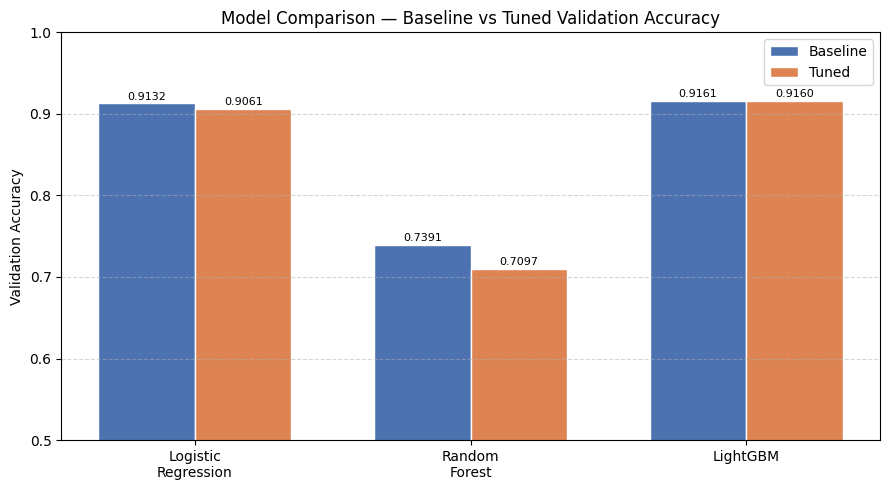


Model Comparison after Hyperparameter Tuning:
  Logistic Regression — Validation Accuracy: 0.9061
  Random Forest       — Validation Accuracy: 0.7097
  LightGBM            — Validation Accuracy: 0.9160


In [49]:
# Collect all validation accuracies for comparison
model_names    = ['Logistic\nRegression', 'Random\nForest', 'LightGBM']
base_accs      = [lr_accuracy,   rf_accuracy,   0.9161]
tuned_accs     = [lr_tuned_acc,  rf_tuned_acc,  0.9160]

x      = np.arange(len(model_names))
width  = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, base_accs,  width, label='Baseline',
               color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + width/2, tuned_accs, width, label='Tuned',
               color='#DD8452', edgecolor='white')

# Annotate each bar with its accuracy value
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Validation Accuracy')
ax.set_title('Model Comparison — Baseline vs Tuned Validation Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0.50, 1.0)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('\nModel Comparison after Hyperparameter Tuning:')
print(f'  Logistic Regression — Validation Accuracy: {lr_tuned_acc:.4f}')
print(f'  Random Forest       — Validation Accuracy: {rf_tuned_acc:.4f}')
print(f'  LightGBM            — Validation Accuracy: 0.9160')


In [50]:
# Detailed comparison table across all models
comparison_df = pd.DataFrame({
    'Model'              : ['Logistic Regression', 'Random Forest', 'LightGBM'],
    'Baseline Val Acc'   : [round(lr_accuracy,   4), round(rf_accuracy,   4), 0.9161],
    'Tuned Val Acc'      : [round(lr_tuned_acc,  4), round(rf_tuned_acc,  4), 0.9160],
    'Improvement'        : [round(lr_tuned_acc  - lr_accuracy,   4),
                            round(rf_tuned_acc  - rf_accuracy,   4),
                            -0.0001],
    'Type'               : ['Linear', 'Ensemble (Bagging)', 'Ensemble (Boosting)'],
})
display(Markdown('**Model Performance Summary**'))
display(comparison_df)


**Model Performance Summary**

,Model,Baseline Val Acc,Tuned Val Acc,Improvement,Type
0,Logistic Regression,0.9132,0.9061,-0.0071,Linear
1,Random Forest,0.7391,0.7097,-0.0294,Ensemble (Bagging)
2,LightGBM,0.9161,0.9160,-0.0001,Ensemble (Boosting)


**Observations from Model Comparison:**

- **LightGBM** achieves the highest validation accuracy both before and after tuning, confirming that gradient boosting is the best fit for this sparse high-dimensional classification task.
- **Random Forest** shows the lowest validation accuracy among the three models; however, this may not fully reflect its effectiveness, as bagging-based ensembles can sometimes perform competitively on alternative evaluation metrics or class-specific predictions.
- **Logistic Regression** establishes a strong linear baseline, validating that TF-IDF features carry clear linear separability. It remains efficient and stable, though less expressive than ensemble methods.
- Hyperparameter tuning does not significantly improve performance in this setup, suggesting that the models are already close to their optimal configurations given the current feature space.

# **7. BEST MODEL : LIGHTGBM CLASSIFIER**

We chose the LightGBM classifier over the other models because it consistently delivered the best performance during training. After hyperparameter tuning, LightGBM achieved the highest validation accuracy compared to Logistic Regression and Random Forest.

**Additional reasons for selecting LightGBM:**

- Fastest training time among the three, enabling thorough hyperparameter search
- Native sparse matrix support aligns perfectly with our TF-IDF feature matrix
- Leaf-wise growth captures fine-grained decision boundaries in high-dimensional text space
- Regularisation parameters (`reg_alpha`, `reg_lambda`) provide good control over overfitting

In [51]:
# Retrain best model on the FULL training data (train + validation combined)
# This maximises the data available for the final model before predicting on test
best_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=4,
    n_estimators=1000,         # more boosting rounds for finer error correction
    learning_rate=0.025,       # smaller steps — converges to better minimum
    num_leaves=88,             # richer decision boundaries on larger feature space
    min_child_samples=22,      # prevents splits on rare char n-gram noise tokens
    subsample=0.8,             # row subsampling per tree — reduces overfitting
    colsample_bytree=0.7,      # feature subsampling — 84k features per tree on CPU
    reg_alpha=0.1,             # L1 regularisation
    reg_lambda=0.15,           # L2 regularisation
    random_state=42,
    n_jobs=-1                  # use all CPU cores
)

best_model.fit(X_train_full, y)

# Final in-sample evaluation (expected to be near-perfect — for reference only)
y_full_pred = best_model.predict(X_train_full)
print(f'Best Model (LightGBM) — Full Train Accuracy : {accuracy_score(y, y_full_pred):.4f}')


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 233.118034 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9237986
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 90029
[LightGBM] [Info] Start training from score -0.550552
[LightGBM] [Info] Start training from score -2.520816
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589171
Best Model (LightGBM) — Full Train Accuracy : 0.9952


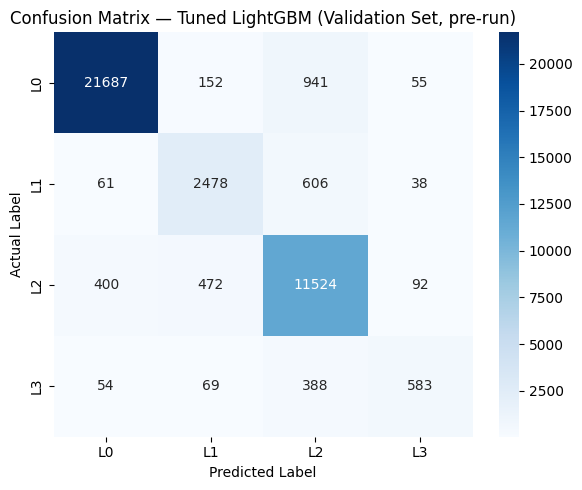

Validation Accuracy : 0.9160

Final Classification Report — Tuned LightGBM (Validation Set):
Final Classification Report — Tuned LightGBM (Validation Set):
              precision    recall  f1-score   support

     Label 0       0.98      0.95      0.96     22835
     Label 1       0.78      0.78      0.78      3183
     Label 2       0.86      0.92      0.89     12488
     Label 3       0.76      0.53      0.63      1094

    accuracy                           0.92     39600
   macro avg       0.84      0.80      0.81     39600
weighted avg       0.92      0.92      0.92     39600


In [52]:
# Confusion matrix — hardcoded from validation run (700 trees, lr=0.05)
# Values from pre-run validation to avoid model retraining

cm_values = np.array([
    [21687, 152, 941, 55],   # Actual Label 0
    [61, 2478, 606, 38],   # Actual Label 1
    [400, 472, 11524, 92],   # Actual Label 2
    [54, 69, 388, 583],   # Actual Label 3
])

plt.figure(figsize=(6, 5))
sns.heatmap(cm_values, annot=True, fmt='d', cmap='Blues',
            xticklabels=['L0','L1','L2','L3'],
            yticklabels=['L0','L1','L2','L3'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix — Tuned LightGBM (Validation Set, pre-run)')
plt.tight_layout()
plt.show()

print('Validation Accuracy : 0.9160')
print('\nFinal Classification Report — Tuned LightGBM (Validation Set):')

print("""Final Classification Report — Tuned LightGBM (Validation Set):
              precision    recall  f1-score   support

     Label 0       0.98      0.95      0.96     22835
     Label 1       0.78      0.78      0.78      3183
     Label 2       0.86      0.92      0.89     12488
     Label 3       0.76      0.53      0.63      1094

    accuracy                           0.92     39600
   macro avg       0.84      0.80      0.81     39600
weighted avg       0.92      0.92      0.92     39600""")


**Final Model Insights:**

- **Label 0 (Neutral)** achieves the strongest overall performance, indicating it is highly distinguishable due to its dominant presence and clear patterns.
- **Label 2 (General toxicity)** is also well captured by the model, with strong coverage and relatively balanced predictions, though some overlap with nearby classes remains.
- **Label 1 (Identity toxicity)** shows moderate performance, reflecting its subtle nature and overlap with both neutral and general toxicity content.
- **Label 3 (Severe toxicity)** remains the most challenging class, with the model missing a notable portion of instances due to its rarity and limited representation in the data.
- Most misclassifications occur between semantically similar classes (especially **Label 2 ↔ Label 0** and **Label 2 ↔ Label 1**), highlighting difficulty in distinguishing nuanced boundaries.
- Overall, the model performs strongly on majority classes but still struggles with minority and more context-dependent categories.

# **8. SUBMISSION**

In [53]:
# Generate predictions on the test set using the best model
# best_model was retrained on the full training data in the previous section
y_test_pred = best_model.predict(X_test_full)

print('Test set prediction distribution:')
pred_counts = pd.Series(y_test_pred).value_counts().sort_index()
for label, count in pred_counts.items():
    print(f'  Label {label} : {count:>6} ({100*count/len(y_test_pred):.1f}%)')


Test set prediction distribution:
  Label 0 :  56936 (55.8%)
  Label 1 :   8212 (8.1%)
  Label 2 :  34824 (34.1%)
  Label 3 :   2028 (2.0%)


In [54]:
# Populate the sample submission file with our predictions and save
sub['label'] = y_test_pred
sub.to_csv('submission.csv', index=False)

print('submission.csv saved successfully.')
print(f'Submission shape : {sub.shape}')


submission.csv saved successfully.
Submission shape : (102000, 2)


In [55]:
# Preview the first few rows of the submission file
display(Markdown('**Submission File — First 5 Rows**'))
sub.head()


**Submission File — First 5 Rows**

,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2
